<font size=6><center>**Analysis on route information failure in
IP core networks by NFV-based test environment**</center></font>


<font size=6>**Content:**</font>
* [Business Understanding](#business-understanding)
* [Data Visualization And Understanding](#data-understanding)
* [Data Preparation](#data-preparation)
* [Modeling](#modeling)
* [Evaluation](#evaluation)
* [Deployment](#data-deployment)

# <font size=6 id='business-understanding'>**BUSINESS UNDERSTANDING**</font>

# <font size=6 id='business-understanding'>**DATA UNDERSTANDING**</font>

In [1]:
#importer les bibliothèques principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import os

In [2]:
print(os.getcwd())

C:\Users\asus


In [3]:
#maintenant on va importer les datas physique
p1=pd.read_csv('20200629.p.csv')
p2=pd.read_csv('20200630.p.csv')
p3=pd.read_csv('20200701.p.csv')
p4=pd.read_csv('20200702.p.csv')
p5=pd.read_csv('20200703.p.csv')
p6=pd.read_csv('20200704.p.csv')
p7=pd.read_csv('20200705.p.csv')
p8=pd.read_csv('20200706.p.csv')


#on va analyser et comprendre les variables du dataset


In [4]:
print("Dimension of Physical_data\n", "-"*50)
list_p = [p1,p2,p3,p4,p5,p6,p7,p8]
for i in range(len(list_p)):
    print("\nDimension du Physical data ",i, ":","="*30, ">",list_p[i].shape)

Dimension of Physical_data
 --------------------------------------------------

Dimension du Physical data  0 : ============================== > (787, 145)

Dimension du Physical data  1 : ============================== > (1436, 145)

Dimension du Physical data  2 : ============================== > (1436, 145)

Dimension du Physical data  3 : ============================== > (1439, 145)

Dimension du Physical data  4 : ============================== > (1436, 145)

Dimension du Physical data  5 : ============================== > (1435, 145)

Dimension du Physical data  6 : ============================== > (1435, 145)

Dimension du Physical data  7 : ============================== > (266, 145)


In [5]:
print("Dimension of Physical_data\n", "-"*50)
list_p = [p1,p2,p3,p4,p5,p6,p7,p8]
for i in range(len(list_p)):
    print("\nDimension du Physical data ",i, ":","="*30, ">",list_p[i].info())

Dimension of Physical_data
 --------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787 entries, 0 to 786
Columns: 145 entries, /computes0/service/id to type_code
dtypes: float64(124), int64(20), object(1)
memory usage: 891.6+ KB

Dimension du Physical data  0 : ============================== > None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Columns: 145 entries, /computes0/service/id to type_code
dtypes: float64(124), int64(20), object(1)
memory usage: 1.6+ MB

Dimension du Physical data  1 : ============================== > None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Columns: 145 entries, /computes0/service/id to type_code
dtypes: float64(124), int64(20), object(1)
memory usage: 1.6+ MB

Dimension du Physical data  2 : ============================== > None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1439 entries, 0 to 1438
Columns: 145 entries, /computes0/service/id to

In [6]:
#We'll try to understand the repartition of the value of each columns of the 8 datasets
#The dataset have the same columns, the .info commands showed it to us
#We'll print the std of the first column
print("Standard deviation of the first column of each data set:", "="*50,">")
print("Std of p1: ",p1['/computes0/service/id'].std())
print("Std of p2: ",p2['/computes0/service/id'].std())
print("Std of p3: ",p3['/computes0/service/id'].std())
print("Std of p4: ",p4['/computes0/service/id'].std())
print("Std of p5: ",p5['/computes0/service/id'].std())
print("Std of p6: ",p6['/computes0/service/id'].std())
print("Std of p7: ",p7['/computes0/service/id'].std())
print("Std of p8: ",p8['/computes0/service/id'].std())


Standard deviation of the first column of each data set: ================================================== >
Std of p1:  0.0
Std of p2:  0.0
Std of p3:  0.0
Std of p4:  0.0
Std of p5:  0.0
Std of p6:  0.0
Std of p7:  0.0
Std of p8:  0.0


In [7]:
df_p = pd.concat([p1,p2,p3,p4,p5,p6,p7,p8], axis=0, ignore_index=True)



In [8]:
df_p

,/computes0/service/id,/computes0/vcpus_used,/computes0/local_gb_used,/computes0/vcpus,/computes0/memory_mb_used,/computes0/memory_mb,/computes0/current_workload,/computes0/cpu_info/topology/cores,/computes0/cpu_info/topology/cells,/computes0/cpu_info/topology/threads,...,/computes0/metrics/hardware-ipmi-temperature#06-p2_dimm_1-6_(0x8)/hardware-ipmi-temperature,/computes0/metrics/hardware-ipmi-temperature#29-battery_zone_(0x1f)/hardware-ipmi-temperature,/computes0/metrics/hardware-ipmi-temperature#21-pci_1_(0x17)/hardware-ipmi-temperature,/computes0/metrics/hardware-ipmi-temperature#10-chipset_(0xc)/hardware-ipmi-temperature,/computes0/metrics/hardware-ipmi-temperature#35-i_o_zone_(0x25)/hardware-ipmi-temperature,/computes0/metrics/hardware-ipmi-temperature#09-exp_bay_drive_(0xb)/hardware-ipmi-temperature,/computes0/metrics/hardware-ipmi-current#power_meter_(0x43)/hardware-ipmi-current,/time,type,type_code
0,16,20,0,48,41472,257790,0,12,2,2,...,41.0,37.0,66.0,38.0,33.0,35.0,225.0,1593395580,ixnetwork-traffic-start,0
1,16,20,0,48,41472,257790,0,12,2,2,...,41.0,37.0,66.0,38.0,33.0,35.0,225.0,1593395640,ixnetwork-traffic-start,0
2,16,20,0,48,41472,257790,0,12,2,2,...,41.0,37.0,66.0,38.0,33.0,36.0,225.0,1593395700,ixnetwork-traffic-start,0
3,16,20,0,48,41472,257790,0,12,2,2,...,41.0,37.0,66.0,38.0,33.0,36.0,235.0,1593395760,ixnetwork-traffic-start,0
4,16,20,0,48,41472,257790,0,12,2,2,...,41.0,37.0,66.0,38.0,33.0,36.0,225.0,1593395820,ixnetwork-traffic-start,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9665,16,20,0,48,41472,257790,0,12,2,2,...,41.0,37.0,66.0,38.0,33.0,36.0,220.0,1593977040,ixnetwork-bgp-hijacking-start,11
9666,16,20,0,48,41472,257790,0,12,2,2,...,41.0,37.0,66.0,38.0,33.0,36.0,220.0,1593977100,ixnetwork-bgp-hijacking-start,11
9667,16,20,0,48,41472,257790,0,12,2,2,...,41.0,37.0,66.0,38.0,33.0,35.0,220.0,1593977160,ixnetwork-bgp-hijacking-start,11
9668,16,20,0,48,41472,257790,0,12,2,2,...,41.0,37.0,66.0,38.0,33.0,35.0,215.0,1593977220,ixnetwork-bgp-hijacking-stop,12


In [9]:
print(os.getcwd())

C:\Users\asus


In [10]:
#on va sauvegarder notre dataset physical
df_p.to_csv(r'C:/Users/ASUS/Desktop/Physical_data.csv')

In [11]:
#for security we'll copy the new dataset on a new variable
physical = df_p.copy()

Understanding of the new dataset

In [12]:
physical.shape

(9670, 145)

# Physical 1 

In [13]:
df_p.head()

,/computes0/service/id,/computes0/vcpus_used,/computes0/local_gb_used,/computes0/vcpus,/computes0/memory_mb_used,/computes0/memory_mb,/computes0/current_workload,/computes0/cpu_info/topology/cores,/computes0/cpu_info/topology/cells,/computes0/cpu_info/topology/threads,...,/computes0/metrics/hardware-ipmi-temperature#06-p2_dimm_1-6_(0x8)/hardware-ipmi-temperature,/computes0/metrics/hardware-ipmi-temperature#29-battery_zone_(0x1f)/hardware-ipmi-temperature,/computes0/metrics/hardware-ipmi-temperature#21-pci_1_(0x17)/hardware-ipmi-temperature,/computes0/metrics/hardware-ipmi-temperature#10-chipset_(0xc)/hardware-ipmi-temperature,/computes0/metrics/hardware-ipmi-temperature#35-i_o_zone_(0x25)/hardware-ipmi-temperature,/computes0/metrics/hardware-ipmi-temperature#09-exp_bay_drive_(0xb)/hardware-ipmi-temperature,/computes0/metrics/hardware-ipmi-current#power_meter_(0x43)/hardware-ipmi-current,/time,type,type_code
0,16,20,0,48,41472,257790,0,12,2,2,...,41.0,37.0,66.0,38.0,33.0,35.0,225.0,1593395580,ixnetwork-traffic-start,0
1,16,20,0,48,41472,257790,0,12,2,2,...,41.0,37.0,66.0,38.0,33.0,35.0,225.0,1593395640,ixnetwork-traffic-start,0
2,16,20,0,48,41472,257790,0,12,2,2,...,41.0,37.0,66.0,38.0,33.0,36.0,225.0,1593395700,ixnetwork-traffic-start,0
3,16,20,0,48,41472,257790,0,12,2,2,...,41.0,37.0,66.0,38.0,33.0,36.0,235.0,1593395760,ixnetwork-traffic-start,0
4,16,20,0,48,41472,257790,0,12,2,2,...,41.0,37.0,66.0,38.0,33.0,36.0,225.0,1593395820,ixnetwork-traffic-start,0


In [14]:
df_p.shape


(9670, 145)

In [15]:
df_p.dtypes.value_counts()


float64    124
int64       20
object       1
dtype: int64

<AxesSubplot:ylabel='None'>

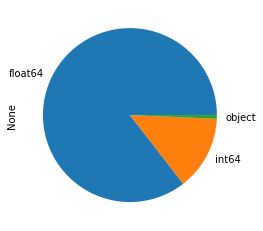

In [16]:
df_p.dtypes.value_counts().plot.pie()


<AxesSubplot:>

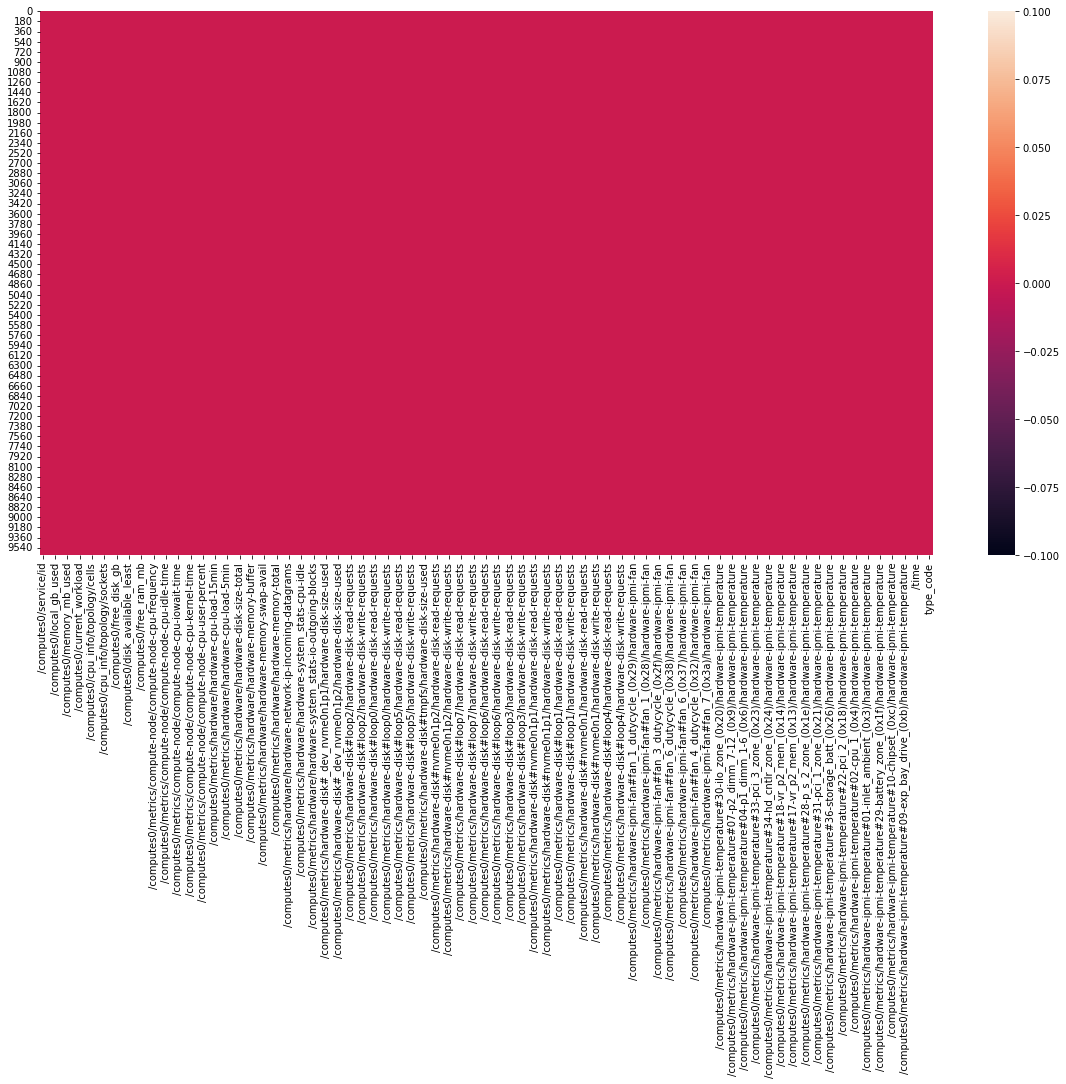

In [17]:
plt.figure(figsize=(20,10))
sns.heatmap(df_p.isna(), cbar=True)


In [18]:
df_p.isna().sum()/df_p.shape[0]


/computes0/service/id                                                                            0.0
/computes0/vcpus_used                                                                            0.0
/computes0/local_gb_used                                                                         0.0
/computes0/vcpus                                                                                 0.0
/computes0/memory_mb_used                                                                        0.0
                                                                                                ... 
/computes0/metrics/hardware-ipmi-temperature#09-exp_bay_drive_(0xb)/hardware-ipmi-temperature    0.0
/computes0/metrics/hardware-ipmi-current#power_meter_(0x43)/hardware-ipmi-current                0.0
/time                                                                                            0.0
type                                                                                       

In [19]:
df_p[df_p.columns[df_p.isna().sum()/df_p.shape[0]<0.9]]


,/computes0/service/id,/computes0/vcpus_used,/computes0/local_gb_used,/computes0/vcpus,/computes0/memory_mb_used,/computes0/memory_mb,/computes0/current_workload,/computes0/cpu_info/topology/cores,/computes0/cpu_info/topology/cells,/computes0/cpu_info/topology/threads,...,/computes0/metrics/hardware-ipmi-temperature#06-p2_dimm_1-6_(0x8)/hardware-ipmi-temperature,/computes0/metrics/hardware-ipmi-temperature#29-battery_zone_(0x1f)/hardware-ipmi-temperature,/computes0/metrics/hardware-ipmi-temperature#21-pci_1_(0x17)/hardware-ipmi-temperature,/computes0/metrics/hardware-ipmi-temperature#10-chipset_(0xc)/hardware-ipmi-temperature,/computes0/metrics/hardware-ipmi-temperature#35-i_o_zone_(0x25)/hardware-ipmi-temperature,/computes0/metrics/hardware-ipmi-temperature#09-exp_bay_drive_(0xb)/hardware-ipmi-temperature,/computes0/metrics/hardware-ipmi-current#power_meter_(0x43)/hardware-ipmi-current,/time,type,type_code
0,16,20,0,48,41472,257790,0,12,2,2,...,41.0,37.0,66.0,38.0,33.0,35.0,225.0,1593395580,ixnetwork-traffic-start,0
1,16,20,0,48,41472,257790,0,12,2,2,...,41.0,37.0,66.0,38.0,33.0,35.0,225.0,1593395640,ixnetwork-traffic-start,0
2,16,20,0,48,41472,257790,0,12,2,2,...,41.0,37.0,66.0,38.0,33.0,36.0,225.0,1593395700,ixnetwork-traffic-start,0
3,16,20,0,48,41472,257790,0,12,2,2,...,41.0,37.0,66.0,38.0,33.0,36.0,235.0,1593395760,ixnetwork-traffic-start,0
4,16,20,0,48,41472,257790,0,12,2,2,...,41.0,37.0,66.0,38.0,33.0,36.0,225.0,1593395820,ixnetwork-traffic-start,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9665,16,20,0,48,41472,257790,0,12,2,2,...,41.0,37.0,66.0,38.0,33.0,36.0,220.0,1593977040,ixnetwork-bgp-hijacking-start,11
9666,16,20,0,48,41472,257790,0,12,2,2,...,41.0,37.0,66.0,38.0,33.0,36.0,220.0,1593977100,ixnetwork-bgp-hijacking-start,11
9667,16,20,0,48,41472,257790,0,12,2,2,...,41.0,37.0,66.0,38.0,33.0,35.0,220.0,1593977160,ixnetwork-bgp-hijacking-start,11
9668,16,20,0,48,41472,257790,0,12,2,2,...,41.0,37.0,66.0,38.0,33.0,35.0,215.0,1593977220,ixnetwork-bgp-hijacking-stop,12


<AxesSubplot:>

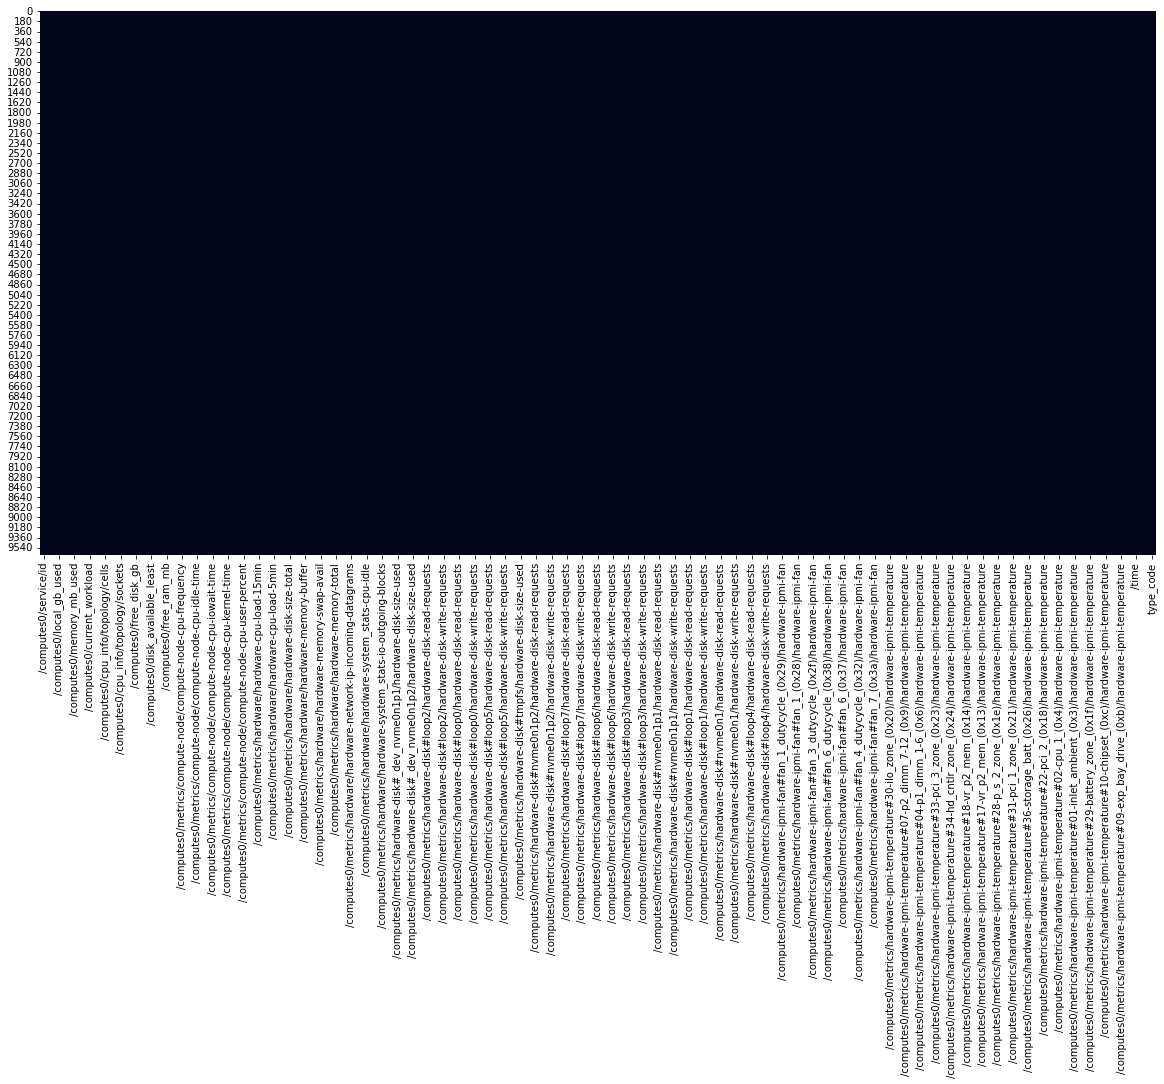

In [20]:
plt.figure(figsize=(20,10))
sns.heatmap(df_p.isna(), cbar=False)
     

C:\Users\asus\AppData\Local\Temp\ipykernel_1432\999105757.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure()


<Figure size 432x288 with 0 Axes>

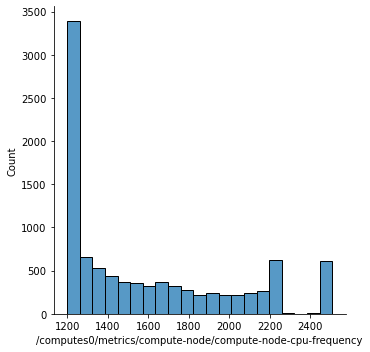

<Figure size 432x288 with 0 Axes>

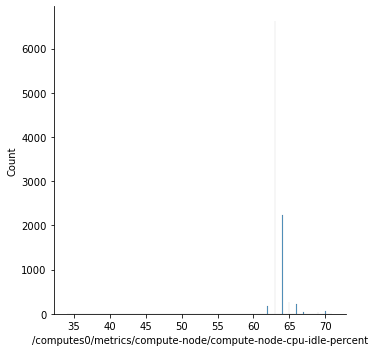

<Figure size 432x288 with 0 Axes>

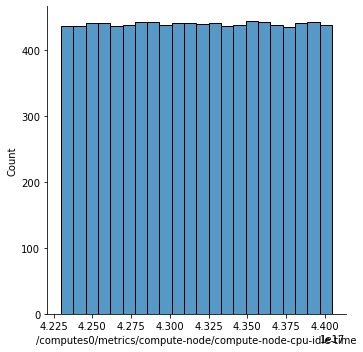

<Figure size 432x288 with 0 Axes>

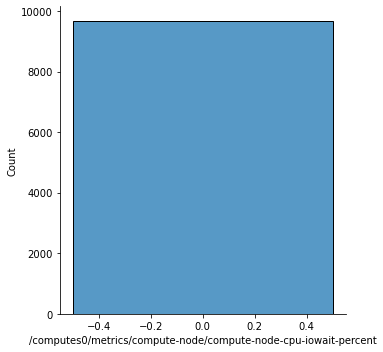

<Figure size 432x288 with 0 Axes>

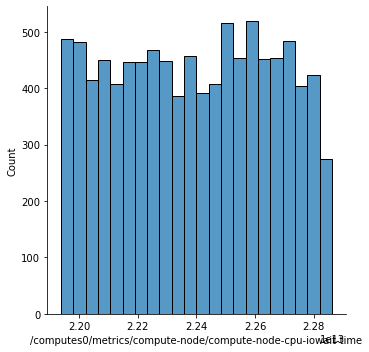

<Figure size 432x288 with 0 Axes>

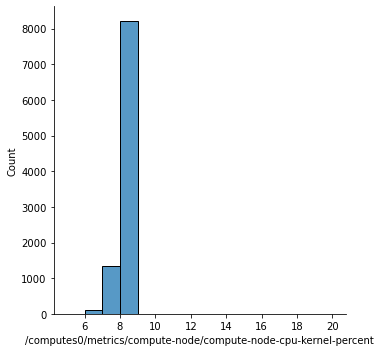

<Figure size 432x288 with 0 Axes>

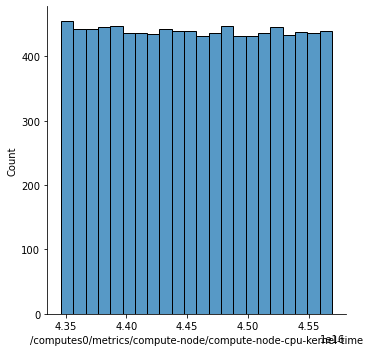

<Figure size 432x288 with 0 Axes>

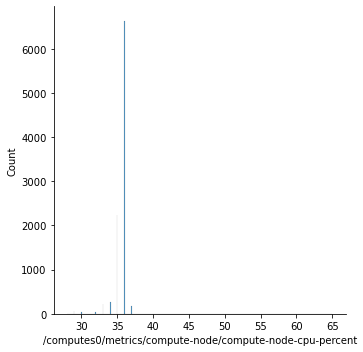

<Figure size 432x288 with 0 Axes>

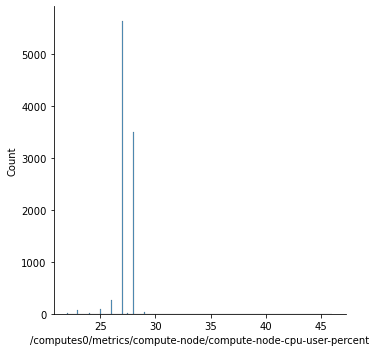

<Figure size 432x288 with 0 Axes>

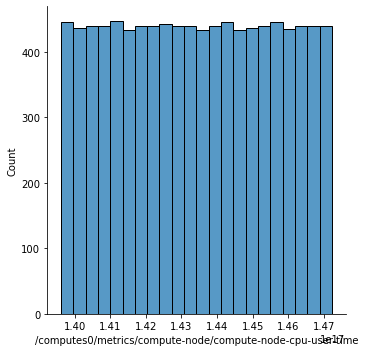

<Figure size 432x288 with 0 Axes>

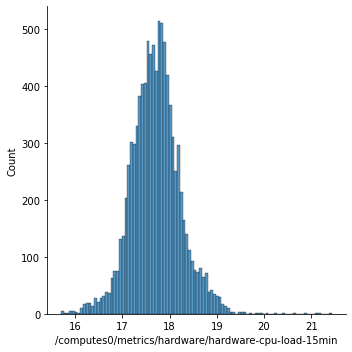

<Figure size 432x288 with 0 Axes>

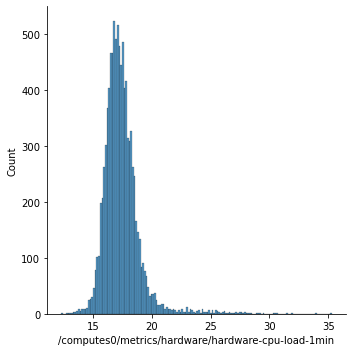

<Figure size 432x288 with 0 Axes>

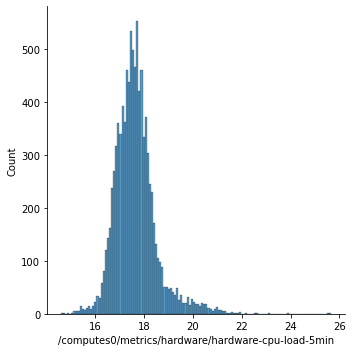

<Figure size 432x288 with 0 Axes>

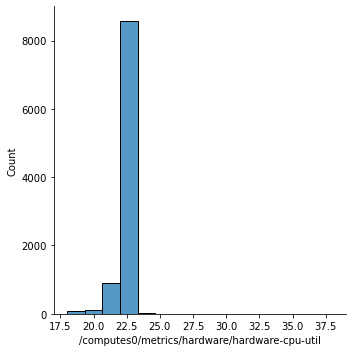

<Figure size 432x288 with 0 Axes>

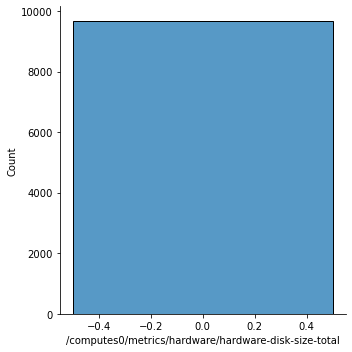

<Figure size 432x288 with 0 Axes>

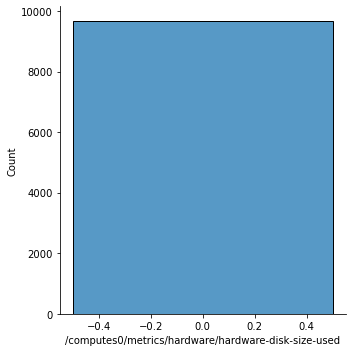

<Figure size 432x288 with 0 Axes>

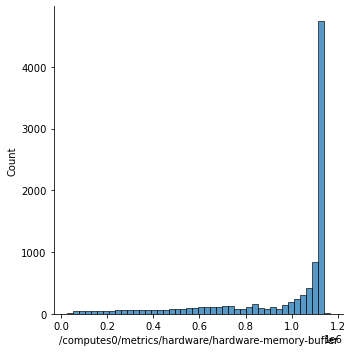

<Figure size 432x288 with 0 Axes>

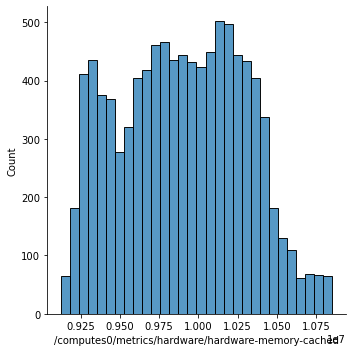

<Figure size 432x288 with 0 Axes>

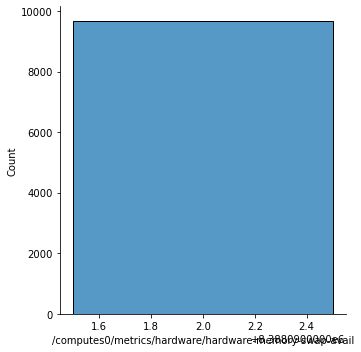

<Figure size 432x288 with 0 Axes>

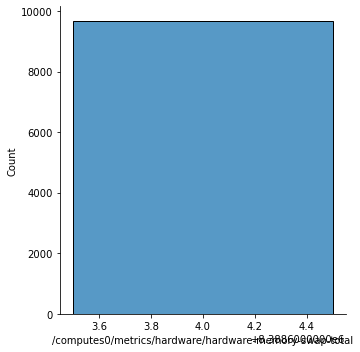

<Figure size 432x288 with 0 Axes>

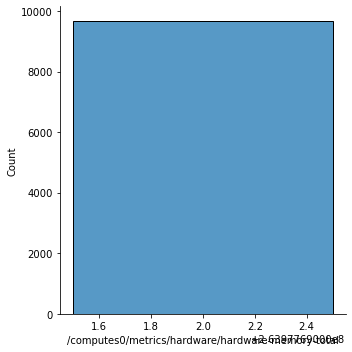

<Figure size 432x288 with 0 Axes>

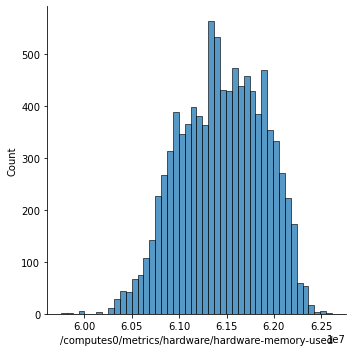

<Figure size 432x288 with 0 Axes>

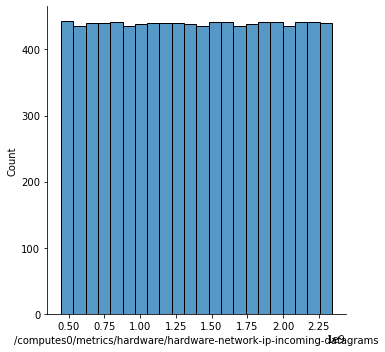

<Figure size 432x288 with 0 Axes>

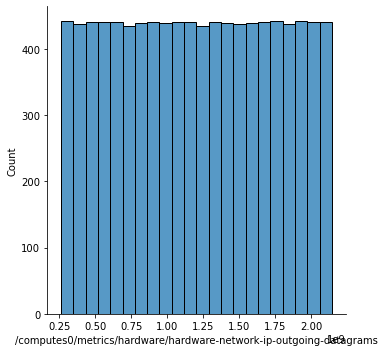

<Figure size 432x288 with 0 Axes>

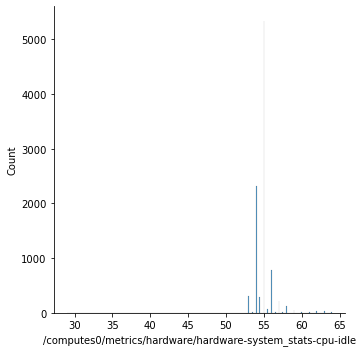

<Figure size 432x288 with 0 Axes>

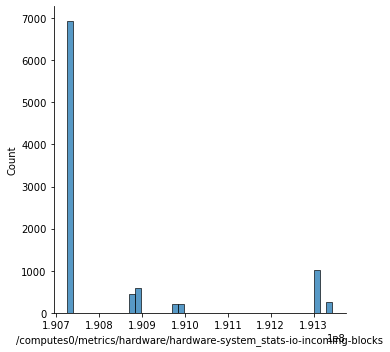

<Figure size 432x288 with 0 Axes>

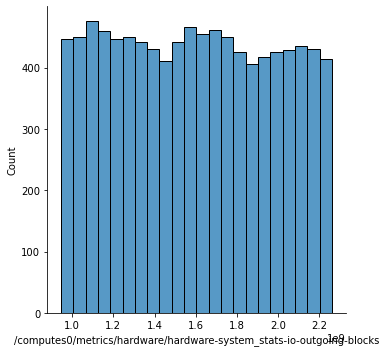

<Figure size 432x288 with 0 Axes>

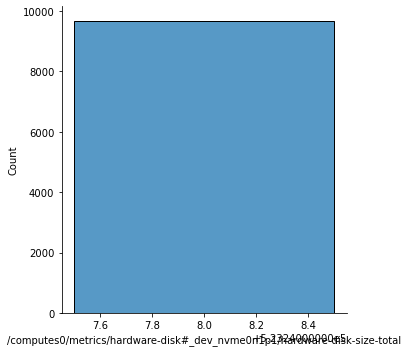

<Figure size 432x288 with 0 Axes>

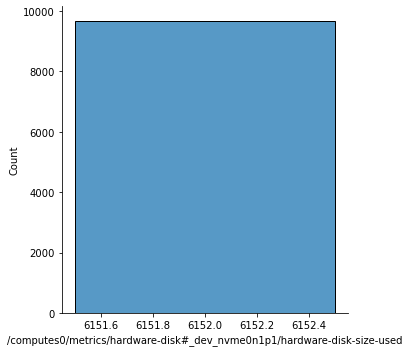

<Figure size 432x288 with 0 Axes>

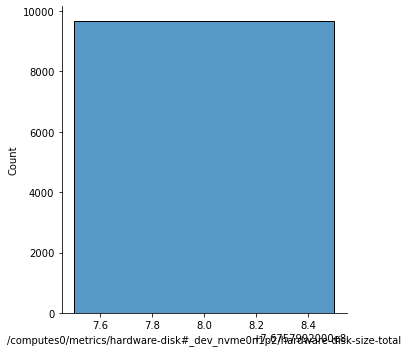

<Figure size 432x288 with 0 Axes>

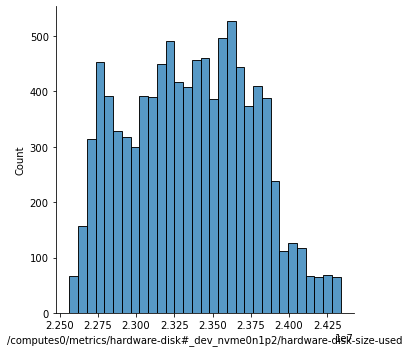

<Figure size 432x288 with 0 Axes>

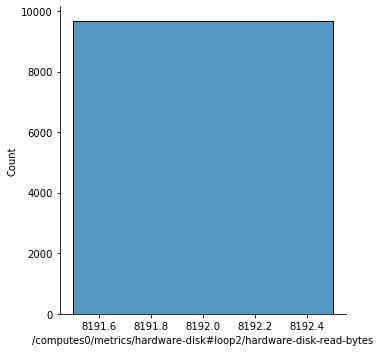

<Figure size 432x288 with 0 Axes>

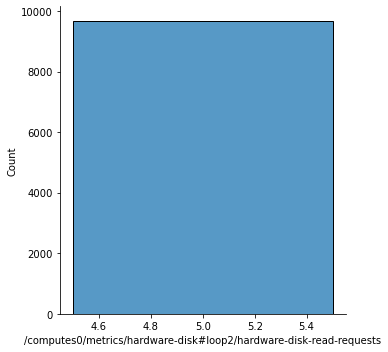

<Figure size 432x288 with 0 Axes>

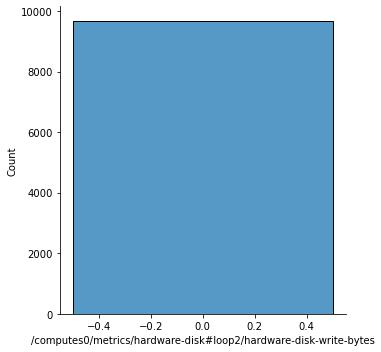

<Figure size 432x288 with 0 Axes>

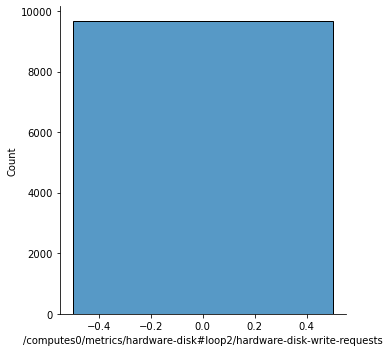

<Figure size 432x288 with 0 Axes>

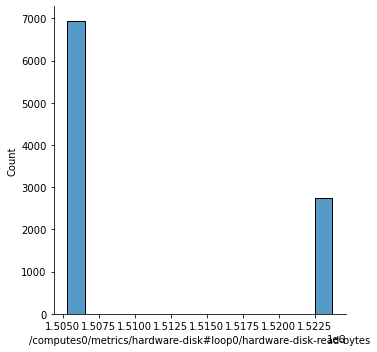

<Figure size 432x288 with 0 Axes>

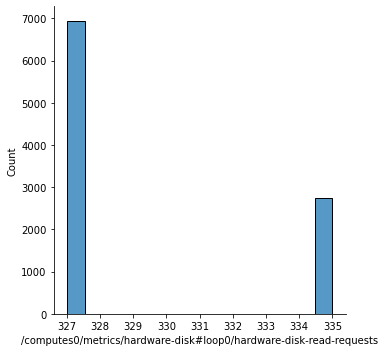

<Figure size 432x288 with 0 Axes>

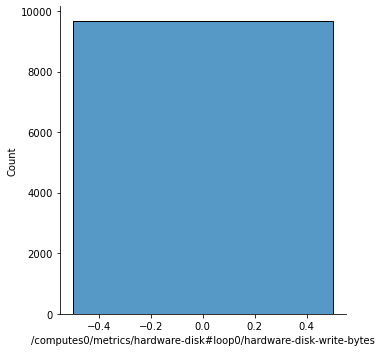

<Figure size 432x288 with 0 Axes>

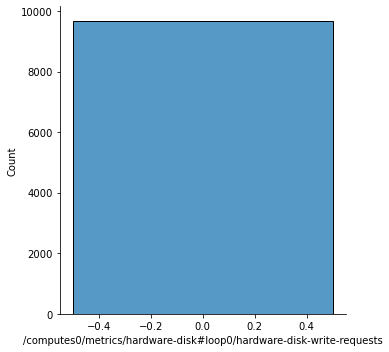

<Figure size 432x288 with 0 Axes>

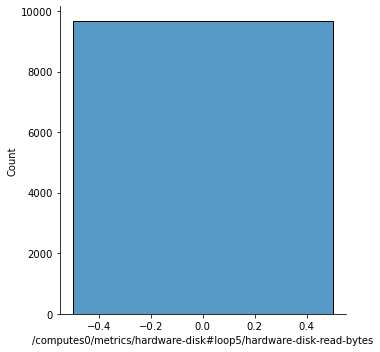

<Figure size 432x288 with 0 Axes>

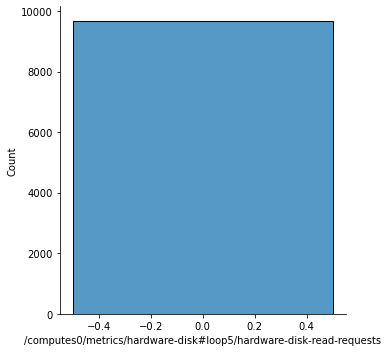

<Figure size 432x288 with 0 Axes>

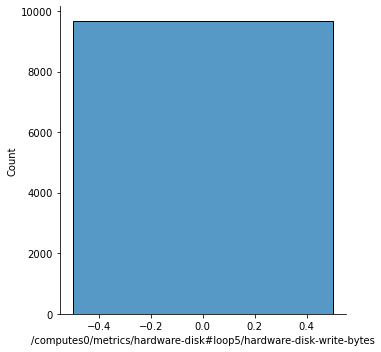

<Figure size 432x288 with 0 Axes>

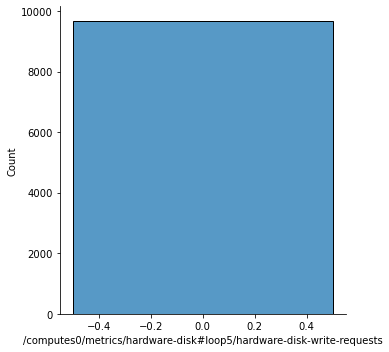

<Figure size 432x288 with 0 Axes>

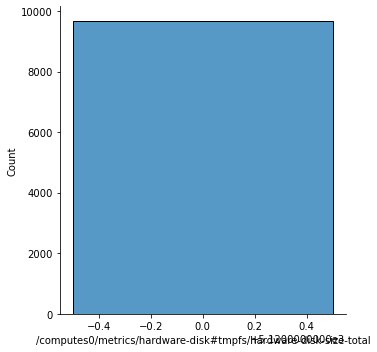

<Figure size 432x288 with 0 Axes>

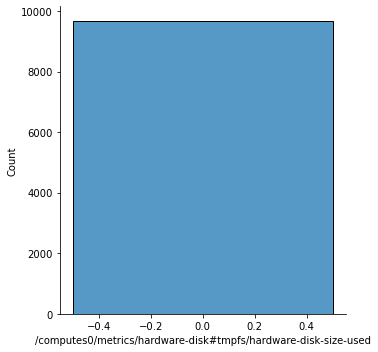

<Figure size 432x288 with 0 Axes>

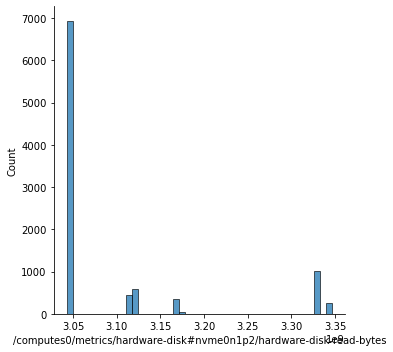

<Figure size 432x288 with 0 Axes>

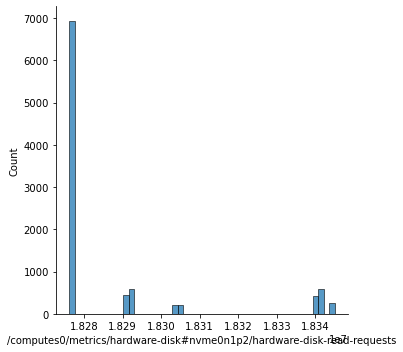

<Figure size 432x288 with 0 Axes>

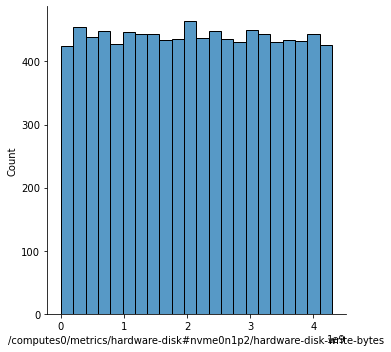

<Figure size 432x288 with 0 Axes>

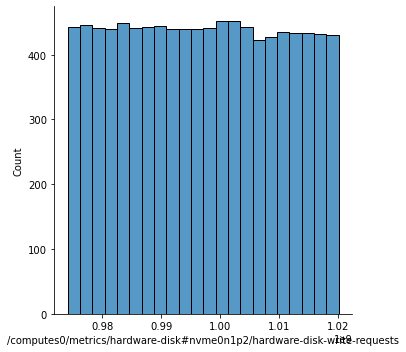

<Figure size 432x288 with 0 Axes>

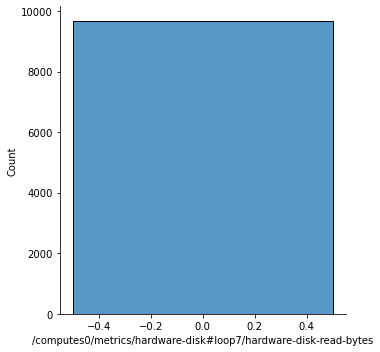

<Figure size 432x288 with 0 Axes>

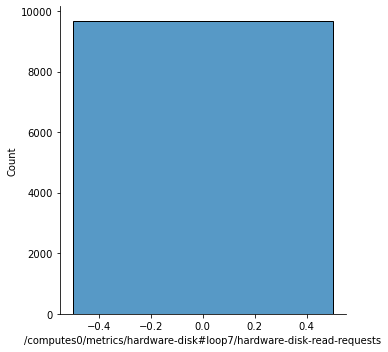

<Figure size 432x288 with 0 Axes>

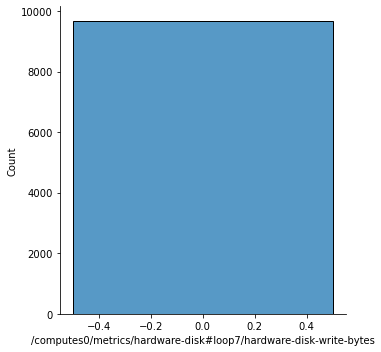

<Figure size 432x288 with 0 Axes>

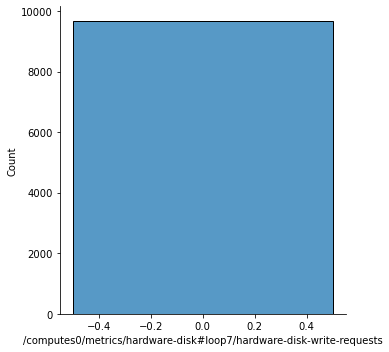

<Figure size 432x288 with 0 Axes>

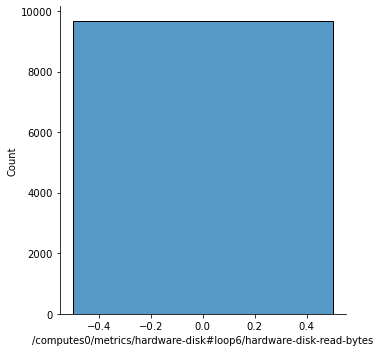

<Figure size 432x288 with 0 Axes>

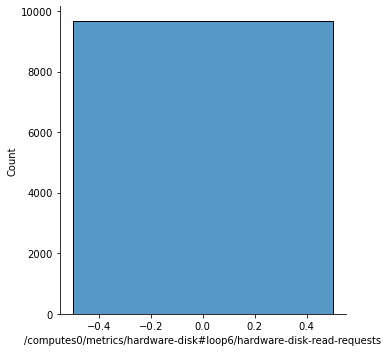

<Figure size 432x288 with 0 Axes>

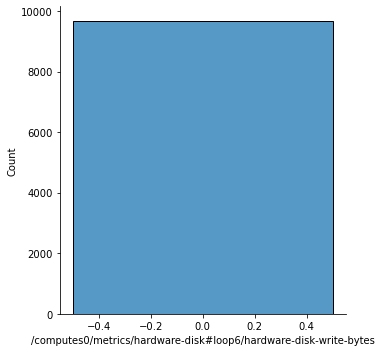

<Figure size 432x288 with 0 Axes>

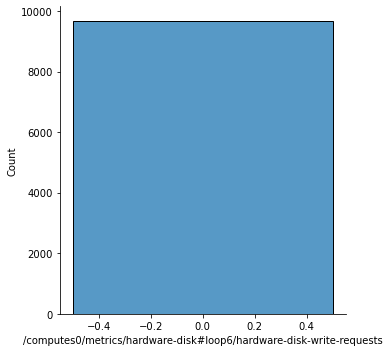

<Figure size 432x288 with 0 Axes>

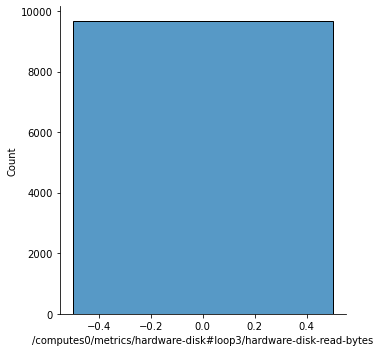

<Figure size 432x288 with 0 Axes>

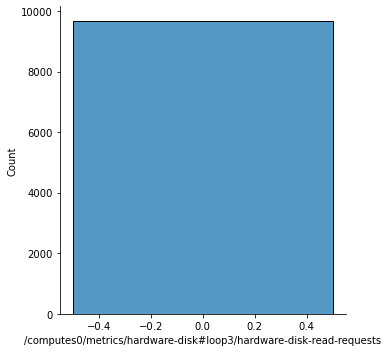

<Figure size 432x288 with 0 Axes>

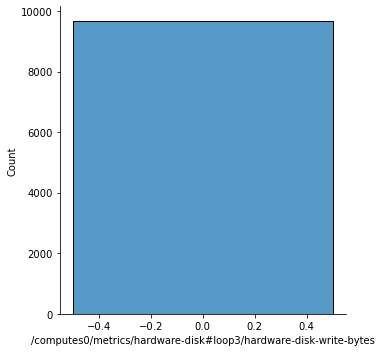

<Figure size 432x288 with 0 Axes>

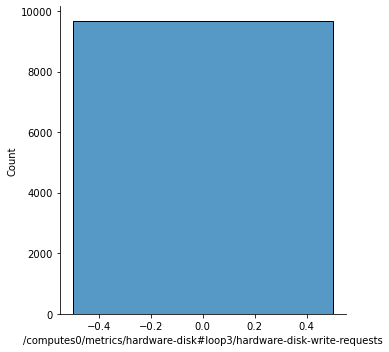

<Figure size 432x288 with 0 Axes>

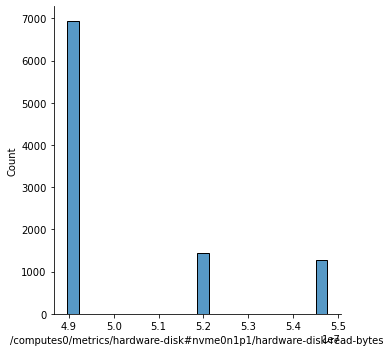

<Figure size 432x288 with 0 Axes>

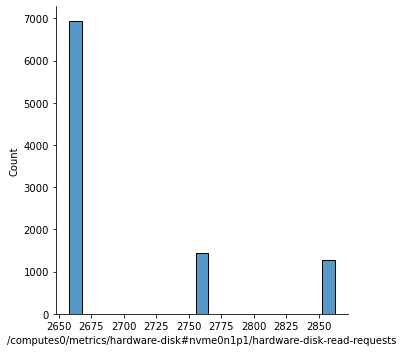

<Figure size 432x288 with 0 Axes>

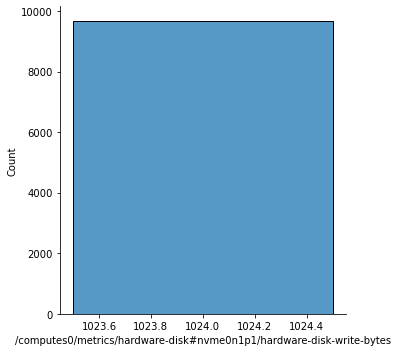

<Figure size 432x288 with 0 Axes>

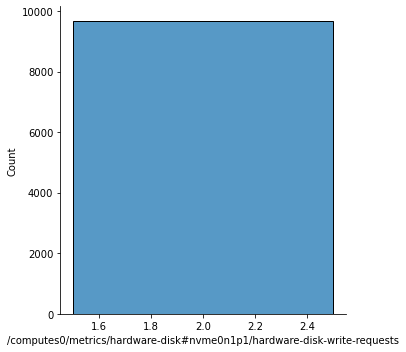

<Figure size 432x288 with 0 Axes>

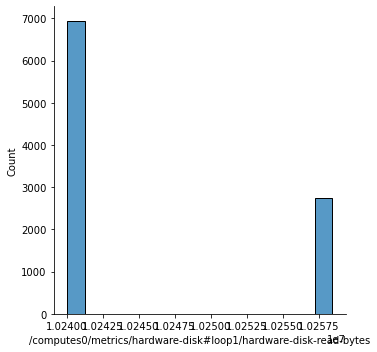

<Figure size 432x288 with 0 Axes>

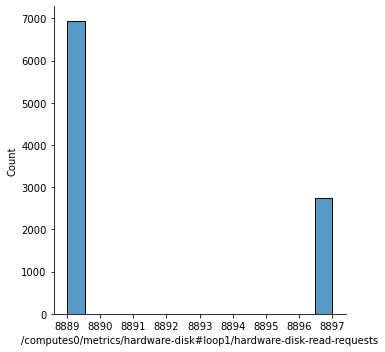

<Figure size 432x288 with 0 Axes>

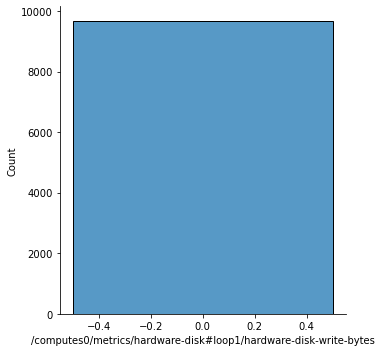

<Figure size 432x288 with 0 Axes>

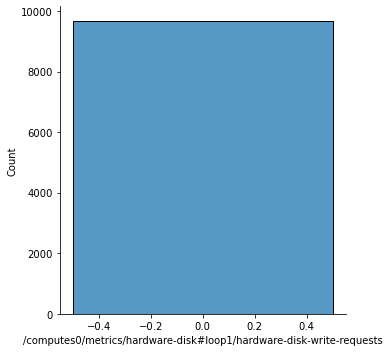

<Figure size 432x288 with 0 Axes>

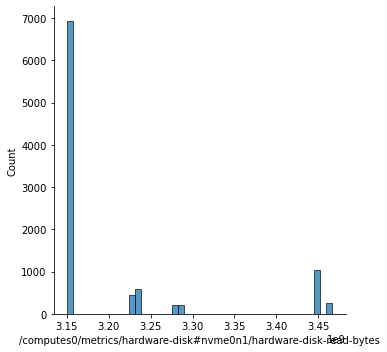

<Figure size 432x288 with 0 Axes>

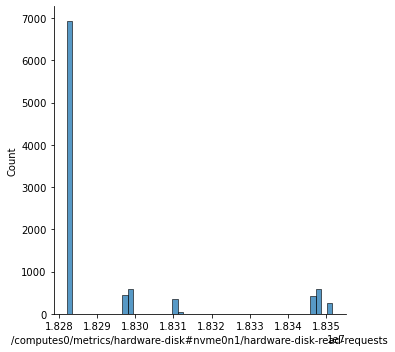

<Figure size 432x288 with 0 Axes>

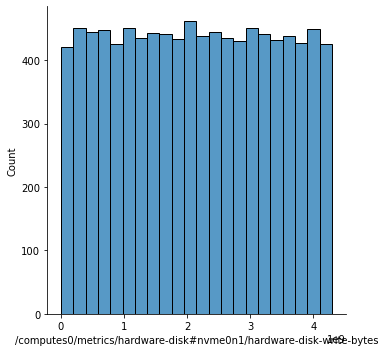

<Figure size 432x288 with 0 Axes>

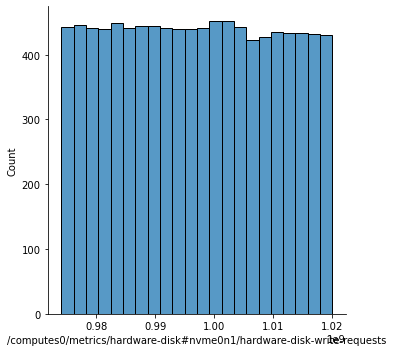

<Figure size 432x288 with 0 Axes>

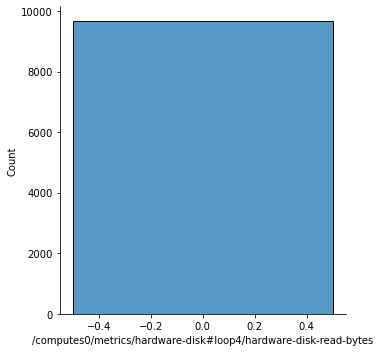

<Figure size 432x288 with 0 Axes>

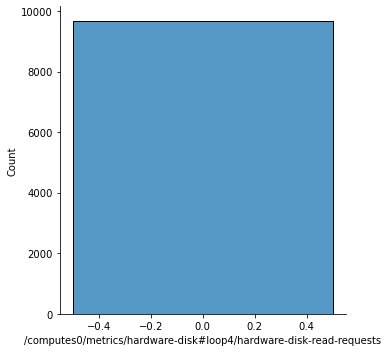

<Figure size 432x288 with 0 Axes>

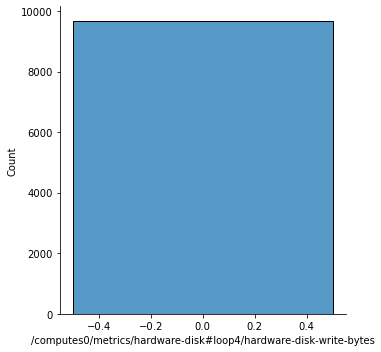

<Figure size 432x288 with 0 Axes>

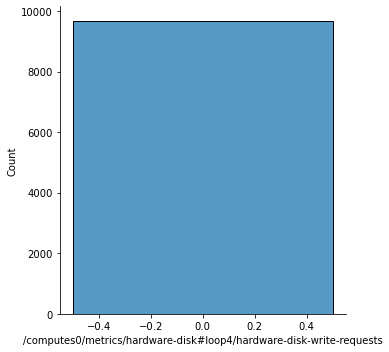

<Figure size 432x288 with 0 Axes>

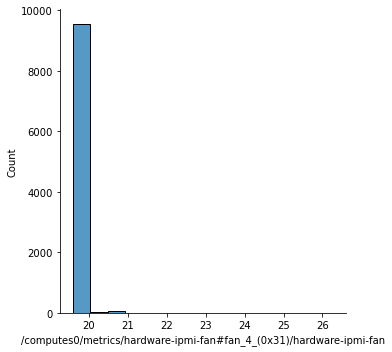

<Figure size 432x288 with 0 Axes>

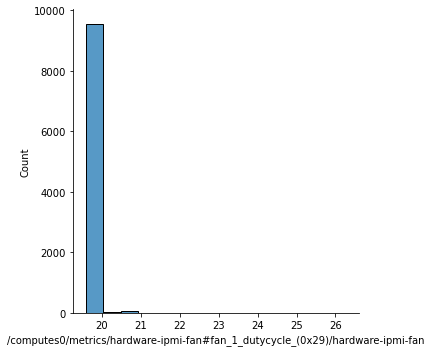

<Figure size 432x288 with 0 Axes>

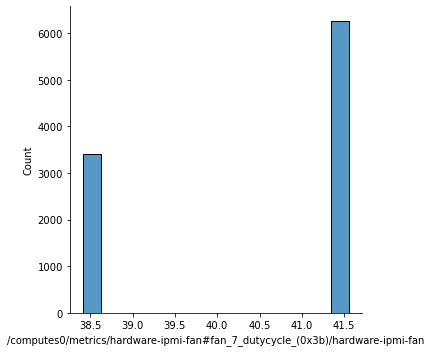

<Figure size 432x288 with 0 Axes>

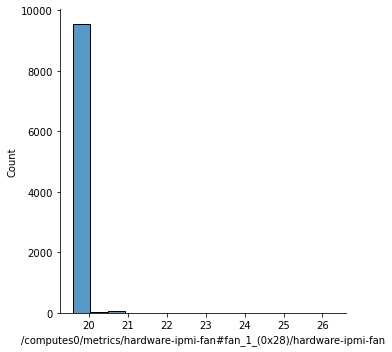

<Figure size 432x288 with 0 Axes>

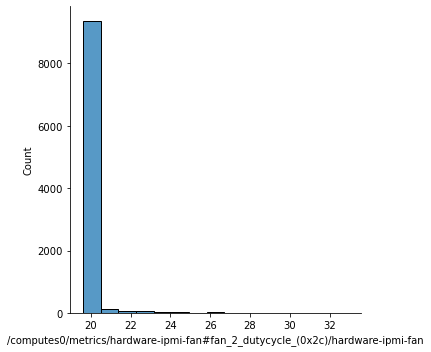

<Figure size 432x288 with 0 Axes>

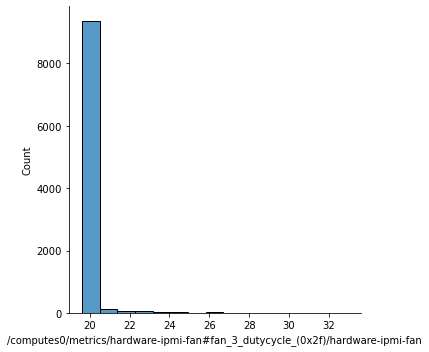

<Figure size 432x288 with 0 Axes>

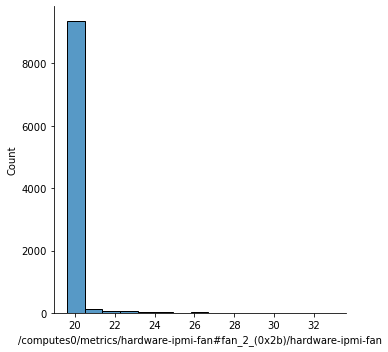

<Figure size 432x288 with 0 Axes>

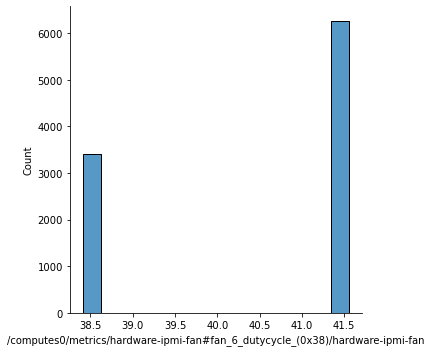

<Figure size 432x288 with 0 Axes>

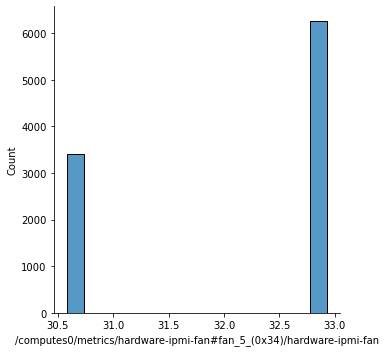

<Figure size 432x288 with 0 Axes>

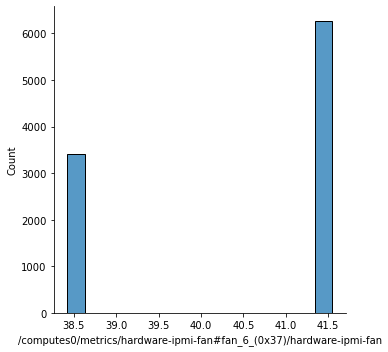

<Figure size 432x288 with 0 Axes>

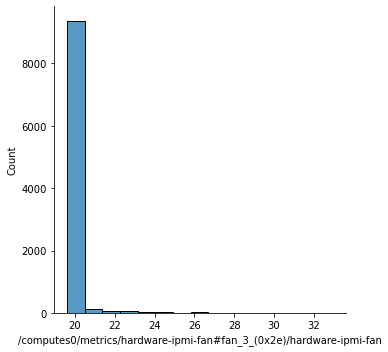

<Figure size 432x288 with 0 Axes>

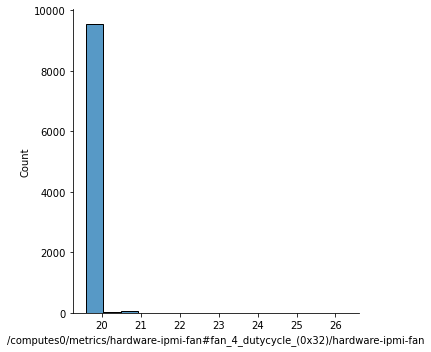

<Figure size 432x288 with 0 Axes>

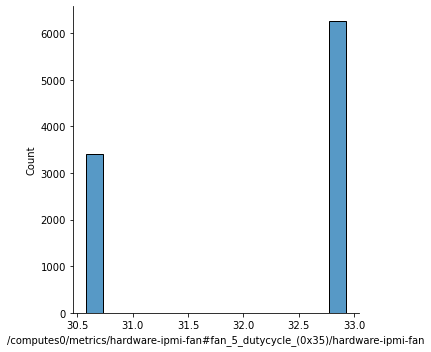

<Figure size 432x288 with 0 Axes>

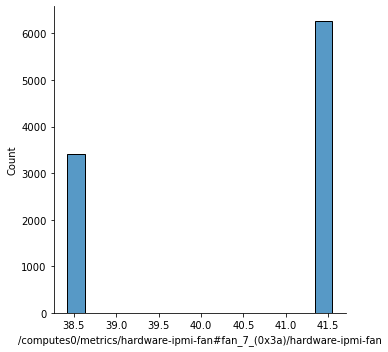

<Figure size 432x288 with 0 Axes>

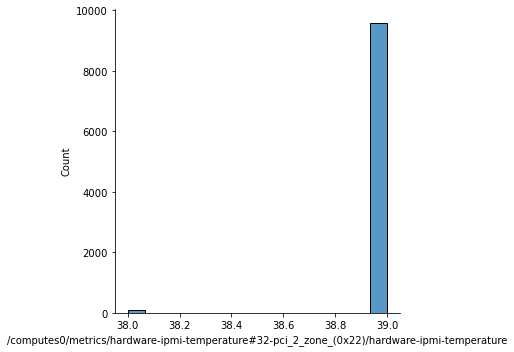

<Figure size 432x288 with 0 Axes>

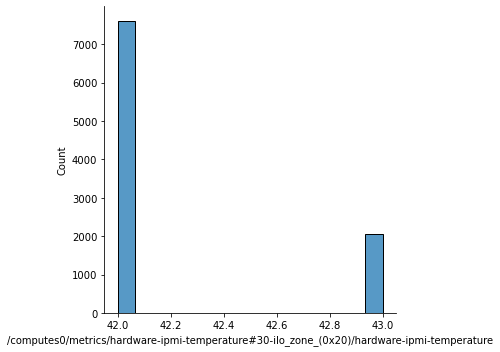

<Figure size 432x288 with 0 Axes>

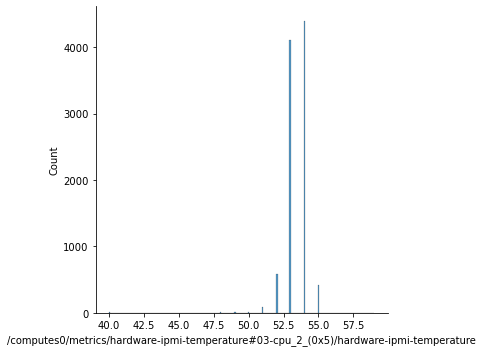

<Figure size 432x288 with 0 Axes>

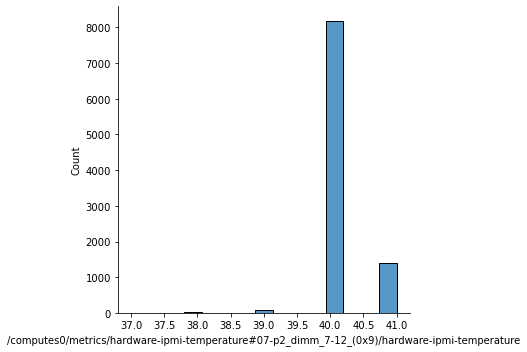

<Figure size 432x288 with 0 Axes>

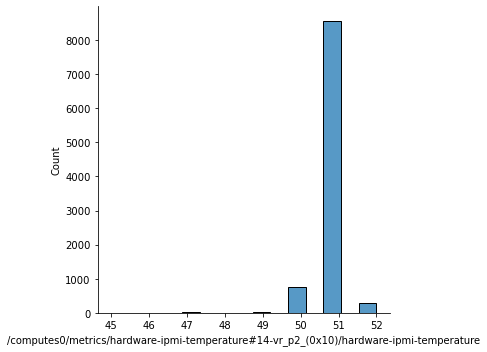

<Figure size 432x288 with 0 Axes>

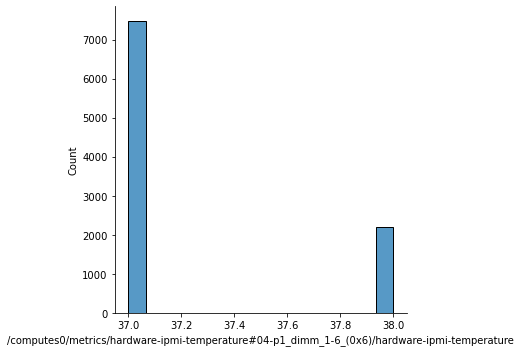

<Figure size 432x288 with 0 Axes>

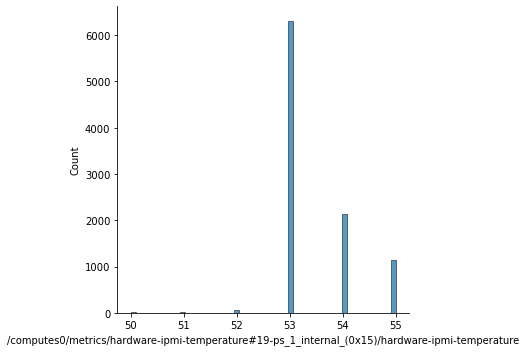

<Figure size 432x288 with 0 Axes>

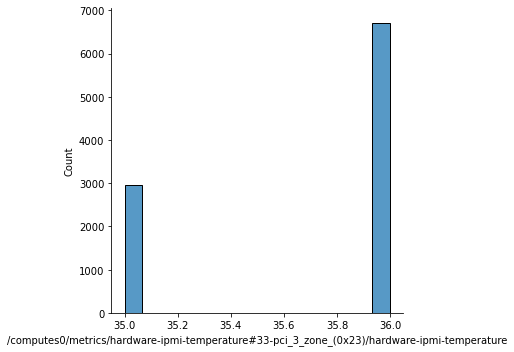

<Figure size 432x288 with 0 Axes>

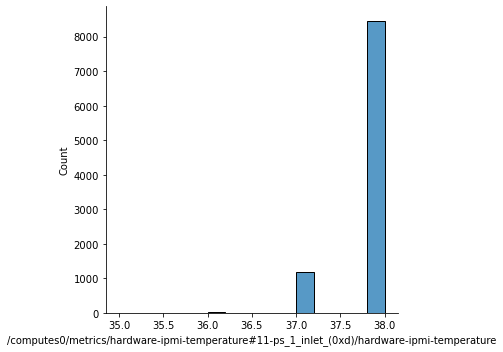

<Figure size 432x288 with 0 Axes>

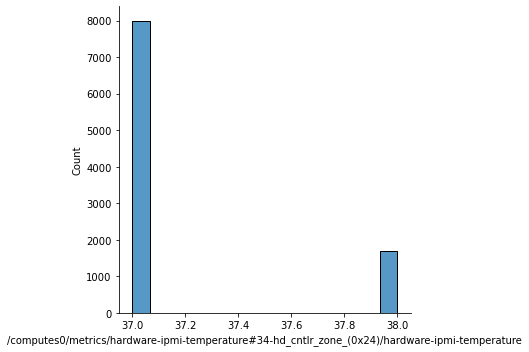

<Figure size 432x288 with 0 Axes>

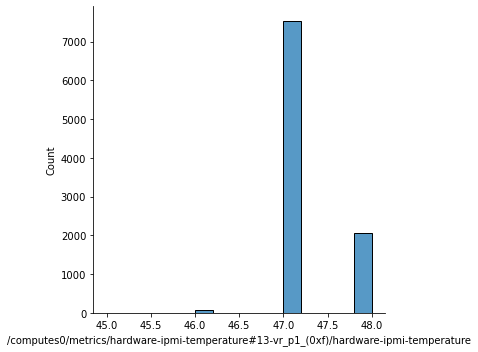

<Figure size 432x288 with 0 Axes>

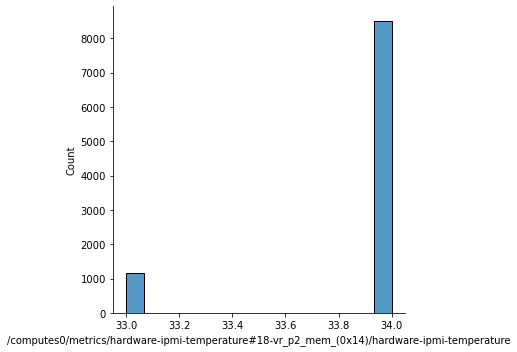

<Figure size 432x288 with 0 Axes>

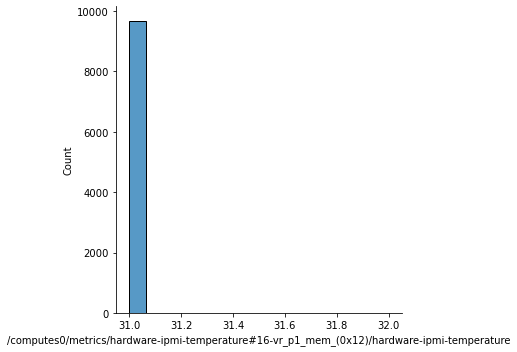

<Figure size 432x288 with 0 Axes>

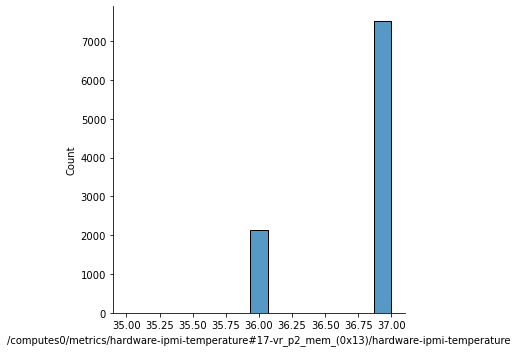

<Figure size 432x288 with 0 Axes>

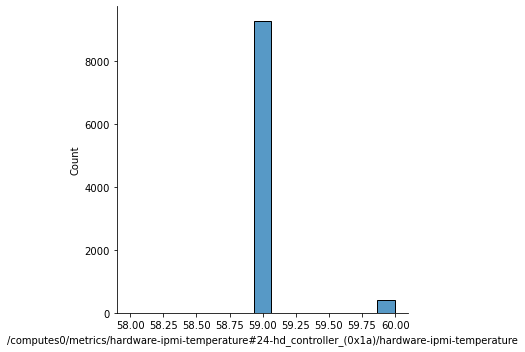

<Figure size 432x288 with 0 Axes>

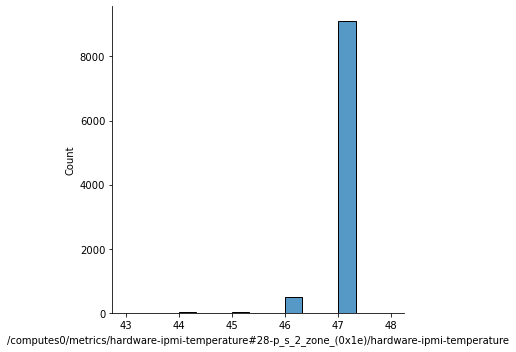

<Figure size 432x288 with 0 Axes>

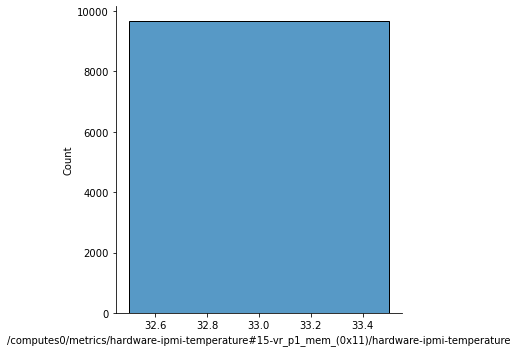

<Figure size 432x288 with 0 Axes>

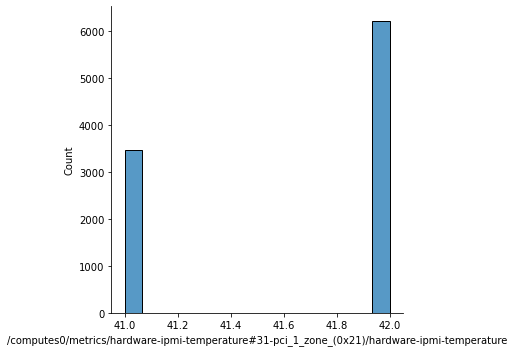

<Figure size 432x288 with 0 Axes>

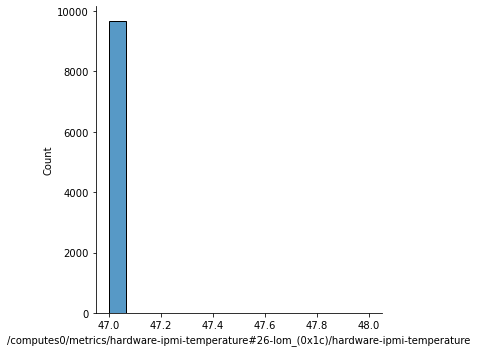

<Figure size 432x288 with 0 Axes>

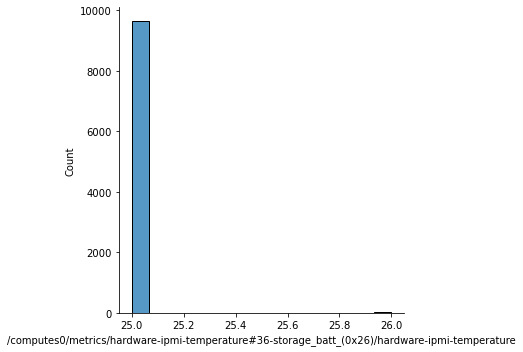

<Figure size 432x288 with 0 Axes>

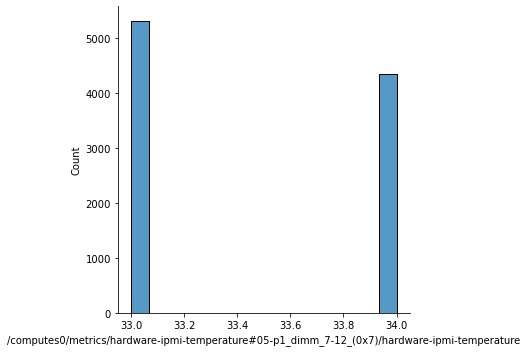

<Figure size 432x288 with 0 Axes>

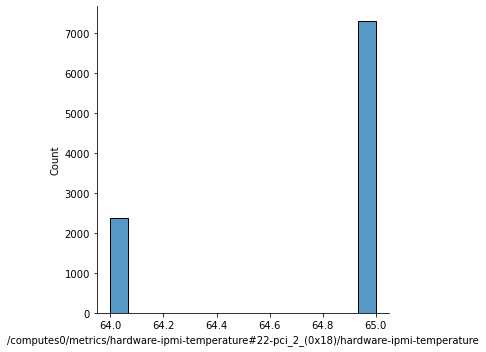

<Figure size 432x288 with 0 Axes>

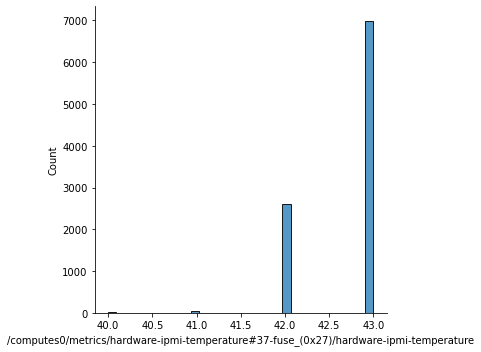

<Figure size 432x288 with 0 Axes>

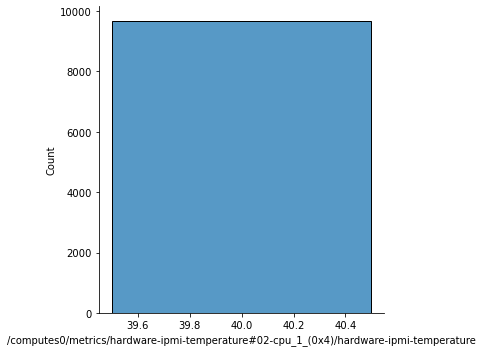

<Figure size 432x288 with 0 Axes>

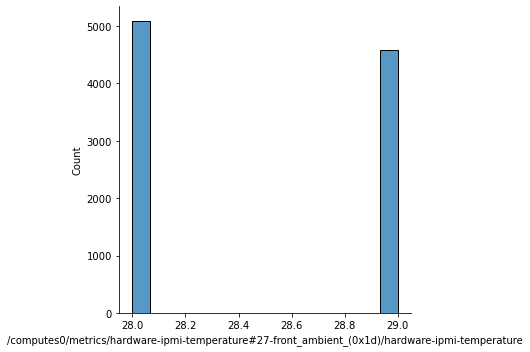

<Figure size 432x288 with 0 Axes>

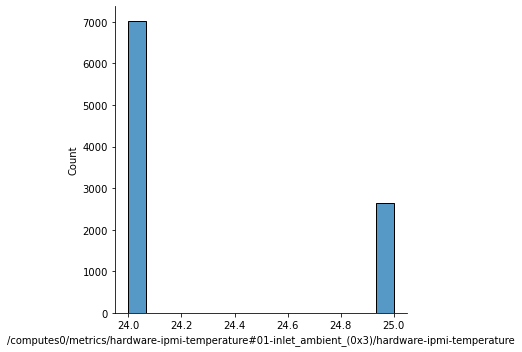

<Figure size 432x288 with 0 Axes>

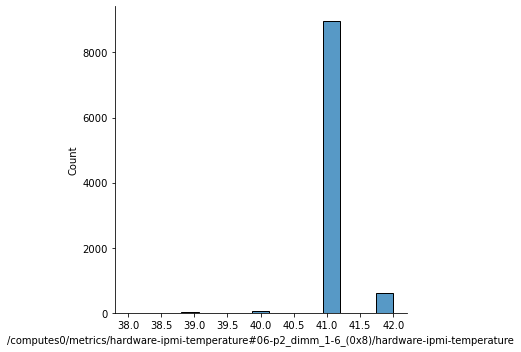

<Figure size 432x288 with 0 Axes>

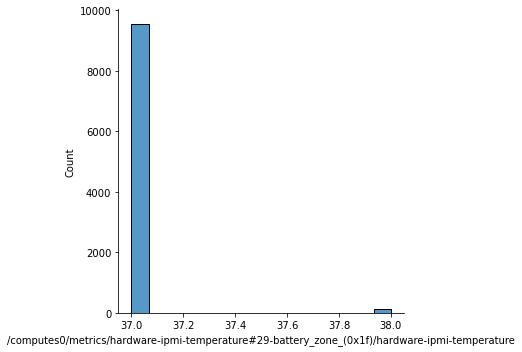

<Figure size 432x288 with 0 Axes>

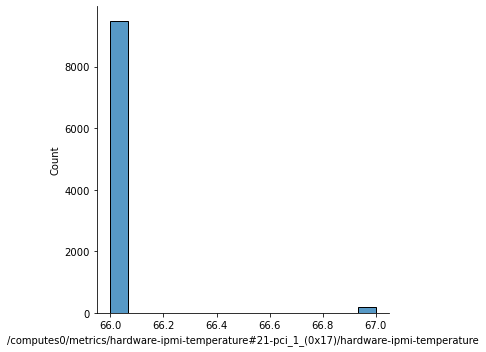

<Figure size 432x288 with 0 Axes>

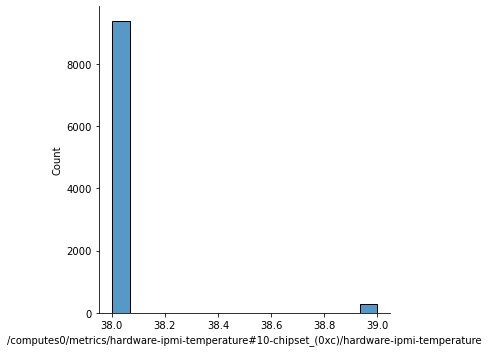

<Figure size 432x288 with 0 Axes>

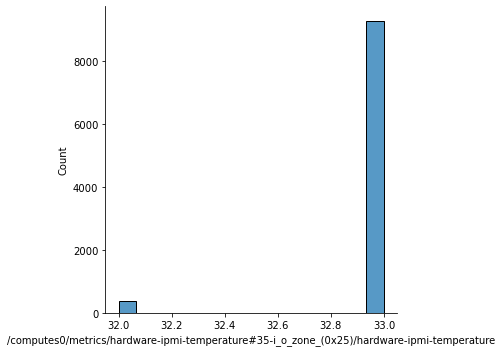

<Figure size 432x288 with 0 Axes>

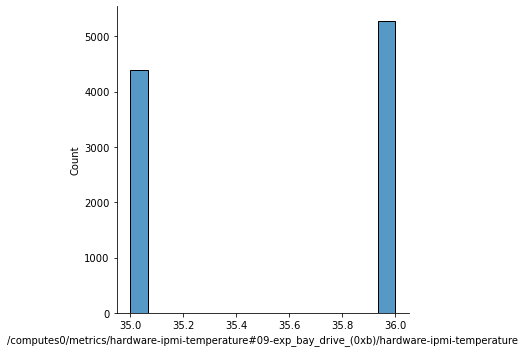

<Figure size 432x288 with 0 Axes>

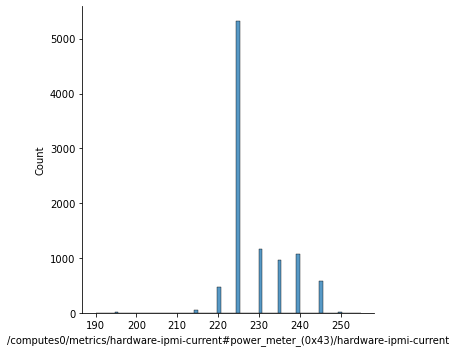

In [21]:
for col in df_p.select_dtypes('float'):
  plt.figure()
  sns.displot(df_p[col])

In [22]:
df_p.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9670 entries, 0 to 9669
Columns: 145 entries, /computes0/service/id to type_code
dtypes: float64(124), int64(20), object(1)
memory usage: 10.7+ MB


In [23]:
#Analytical summary of the dataset 
df_p.describe(include='all')

,/computes0/service/id,/computes0/vcpus_used,/computes0/local_gb_used,/computes0/vcpus,/computes0/memory_mb_used,/computes0/memory_mb,/computes0/current_workload,/computes0/cpu_info/topology/cores,/computes0/cpu_info/topology/cells,/computes0/cpu_info/topology/threads,...,/computes0/metrics/hardware-ipmi-temperature#06-p2_dimm_1-6_(0x8)/hardware-ipmi-temperature,/computes0/metrics/hardware-ipmi-temperature#29-battery_zone_(0x1f)/hardware-ipmi-temperature,/computes0/metrics/hardware-ipmi-temperature#21-pci_1_(0x17)/hardware-ipmi-temperature,/computes0/metrics/hardware-ipmi-temperature#10-chipset_(0xc)/hardware-ipmi-temperature,/computes0/metrics/hardware-ipmi-temperature#35-i_o_zone_(0x25)/hardware-ipmi-temperature,/computes0/metrics/hardware-ipmi-temperature#09-exp_bay_drive_(0xb)/hardware-ipmi-temperature,/computes0/metrics/hardware-ipmi-current#power_meter_(0x43)/hardware-ipmi-current,/time,type,type_code
count,9670.0,9670.0,9670.0,9670.0,9670.0,9670.0,9670.0,9670.0,9670.0,9670.0,...,9670.000000,9670.000000,9670.000000,9670.000000,9670.000000,9670.000000,9670.000000,9.670000e+03,9670,9670.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tap-delay-stop,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1751,NaN
mean,16.0,20.0,0.0,48.0,41472.0,257790.0,0.0,12.0,2.0,2.0,...,41.051293,37.012203,66.019752,38.029679,32.959462,35.545708,229.093588,1.593686e+09,NaN,6.540021
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.281567,0.109795,0.139153,0.169710,0.197227,0.497932,7.041977,1.679281e+05,NaN,2.175989
min,16.0,20.0,0.0,48.0,41472.0,257790.0,0.0,12.0,2.0,2.0,...,38.000000,37.000000,66.000000,38.000000,32.000000,35.000000,190.000000,1.593396e+09,NaN,0.000000
25%,16.0,20.0,0.0,48.0,41472.0,257790.0,0.0,12.0,2.0,2.0,...,41.000000,37.000000,66.000000,38.000000,33.000000,35.000000,225.000000,1.593541e+09,NaN,5.000000
50%,16.0,20.0,0.0,48.0,41472.0,257790.0,0.0,12.0,2.0,2.0,...,41.000000,37.000000,66.000000,38.000000,33.000000,36.000000,225.000000,1.593686e+09,NaN,6.000000
75%,16.0,20.0,0.0,48.0,41472.0,257790.0,0.0,12.0,2.0,2.0,...,41.000000,37.000000,66.000000,38.000000,33.000000,36.000000,235.000000,1.593832e+09,NaN,8.000000


array([[<AxesSubplot:title={'center':'/computes0/service/id'}>,
        <AxesSubplot:title={'center':'/computes0/vcpus_used'}>,
        <AxesSubplot:title={'center':'/computes0/local_gb_used'}>,
        <AxesSubplot:title={'center':'/computes0/vcpus'}>,
        <AxesSubplot:title={'center':'/computes0/memory_mb_used'}>,
        <AxesSubplot:title={'center':'/computes0/memory_mb'}>,
        <AxesSubplot:title={'center':'/computes0/current_workload'}>,
        <AxesSubplot:title={'center':'/computes0/cpu_info/topology/cores'}>,
        <AxesSubplot:title={'center':'/computes0/cpu_info/topology/cells'}>,
        <AxesSubplot:title={'center':'/computes0/cpu_info/topology/threads'}>,
        <AxesSubplot:title={'center':'/computes0/cpu_info/topology/sockets'}>,
        <AxesSubplot:title={'center':'/computes0/running_vms'}>],
       [<AxesSubplot:title={'center':'/computes0/free_disk_gb'}>,
        <AxesSubplot:title={'center':'/computes0/hypervisor_version'}>,
        <AxesSubplot:title={'

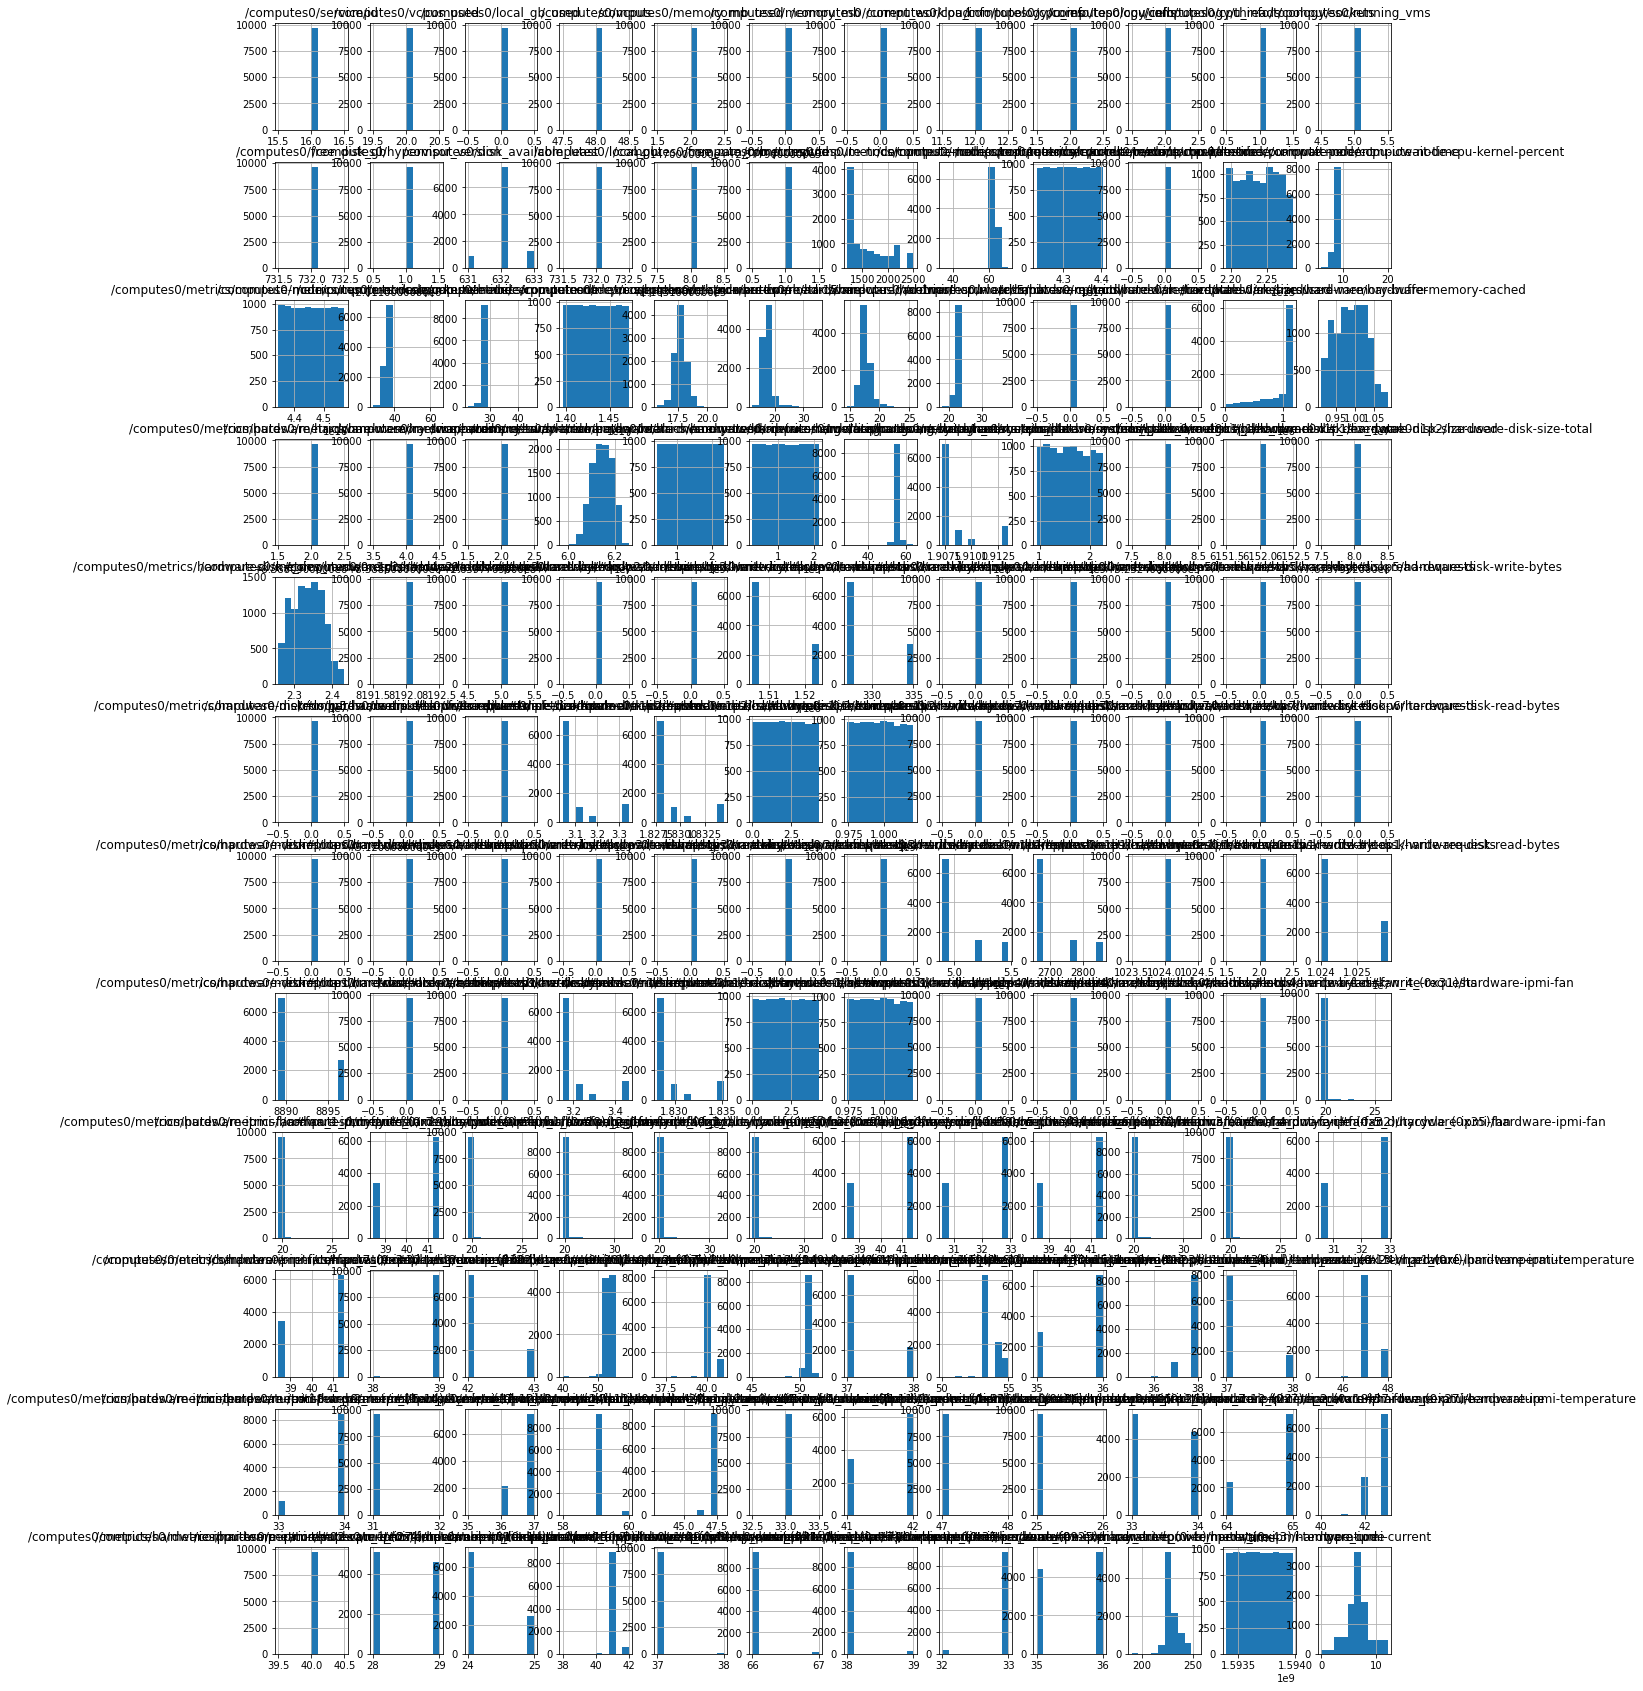

In [24]:
df_p.hist(figsize=(20,30))


In [25]:
for col in df_p.select_dtypes('object'):
  print(f'{col :-<50} {df_p[col].unique()}')
     

type---------------------------------------------- ['ixnetwork-traffic-start' 'node-down' 'node-up' 'interface-down'
 'interface-up' 'tap-loss-start' 'tap-loss-stop' 'tap-delay-start'
 'tap-delay-stop' 'ixnetwork-bgp-injection-start'
 'ixnetwork-bgp-injection-stop' 'ixnetwork-bgp-hijacking-start'
 'ixnetwork-bgp-hijacking-stop']


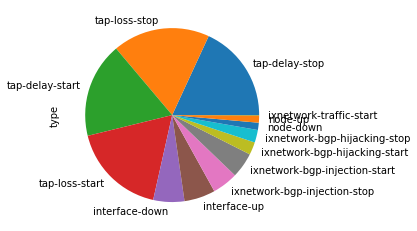

In [26]:
for col in df_p.select_dtypes('object'):
  plt.figure()
  df_p[col].value_counts().plot.pie()

In [27]:
#Rows containing duplicate data
duplicate_rows_df_p = df_p[df_p.duplicated()]
print("Number of duplicate rows: ", duplicate_rows_df_p.shape)

Number of duplicate rows:  (0, 145)


In [28]:
#Drop the duplicates 
#df_p.head()

In [29]:
#Find the null values
print(df_p.isnull().sum())
     

/computes0/service/id                                                                            0
/computes0/vcpus_used                                                                            0
/computes0/local_gb_used                                                                         0
/computes0/vcpus                                                                                 0
/computes0/memory_mb_used                                                                        0
                                                                                                ..
/computes0/metrics/hardware-ipmi-temperature#09-exp_bay_drive_(0xb)/hardware-ipmi-temperature    0
/computes0/metrics/hardware-ipmi-current#power_meter_(0x43)/hardware-ipmi-current                0
/time                                                                                            0
type                                                                                             0
type_code 

In [30]:
#Drop the missing values 
#p1 = p1.dropna()
#p1.count() 

,/computes0/service/id,/computes0/vcpus_used,/computes0/local_gb_used,/computes0/vcpus,/computes0/memory_mb_used,/computes0/memory_mb,/computes0/current_workload,/computes0/cpu_info/topology/cores,/computes0/cpu_info/topology/cells,/computes0/cpu_info/topology/threads,...,/computes0/metrics/hardware-ipmi-temperature#01-inlet_ambient_(0x3)/hardware-ipmi-temperature,/computes0/metrics/hardware-ipmi-temperature#06-p2_dimm_1-6_(0x8)/hardware-ipmi-temperature,/computes0/metrics/hardware-ipmi-temperature#29-battery_zone_(0x1f)/hardware-ipmi-temperature,/computes0/metrics/hardware-ipmi-temperature#21-pci_1_(0x17)/hardware-ipmi-temperature,/computes0/metrics/hardware-ipmi-temperature#10-chipset_(0xc)/hardware-ipmi-temperature,/computes0/metrics/hardware-ipmi-temperature#35-i_o_zone_(0x25)/hardware-ipmi-temperature,/computes0/metrics/hardware-ipmi-temperature#09-exp_bay_drive_(0xb)/hardware-ipmi-temperature,/computes0/metrics/hardware-ipmi-current#power_meter_(0x43)/hardware-ipmi-current,/time,type_code
/computes0/service/id,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
/computes0/vcpus_used,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
/computes0/local_gb_used,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
/computes0/vcpus,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
/computes0/memory_mb_used,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
/computes0/metrics/hardware-ipmi-temperature#35-i_o_zone_(0x25)/hardware-ipmi-temperature,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.068606,0.044896,0.022846,0.029178,0.035949,1.000000,0.215805,0.005934,-0.006600,-0.022969
/computes0/metrics/hardware-ipmi-temperature#09-exp_bay_drive_(0xb)/hardware-ipmi-temperature,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.204452,0.206054,0.095735,0.120560,0.151005,0.215805,1.000000,0.021772,0.014385,-0.018584
/computes0/metrics/hardware-ipmi-current#power_meter_(0x43)/hardware-ipmi-current,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.003123,0.148375,0.017651,-0.041360,-0.047585,0.005934,0.021772,1.000000,-0.118658,0.069541
/time,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.006247,-0.104356,-0.044135,-0.058118,-0.069363,-0.006600,0.014385,-0.118658,1.000000,0.182513


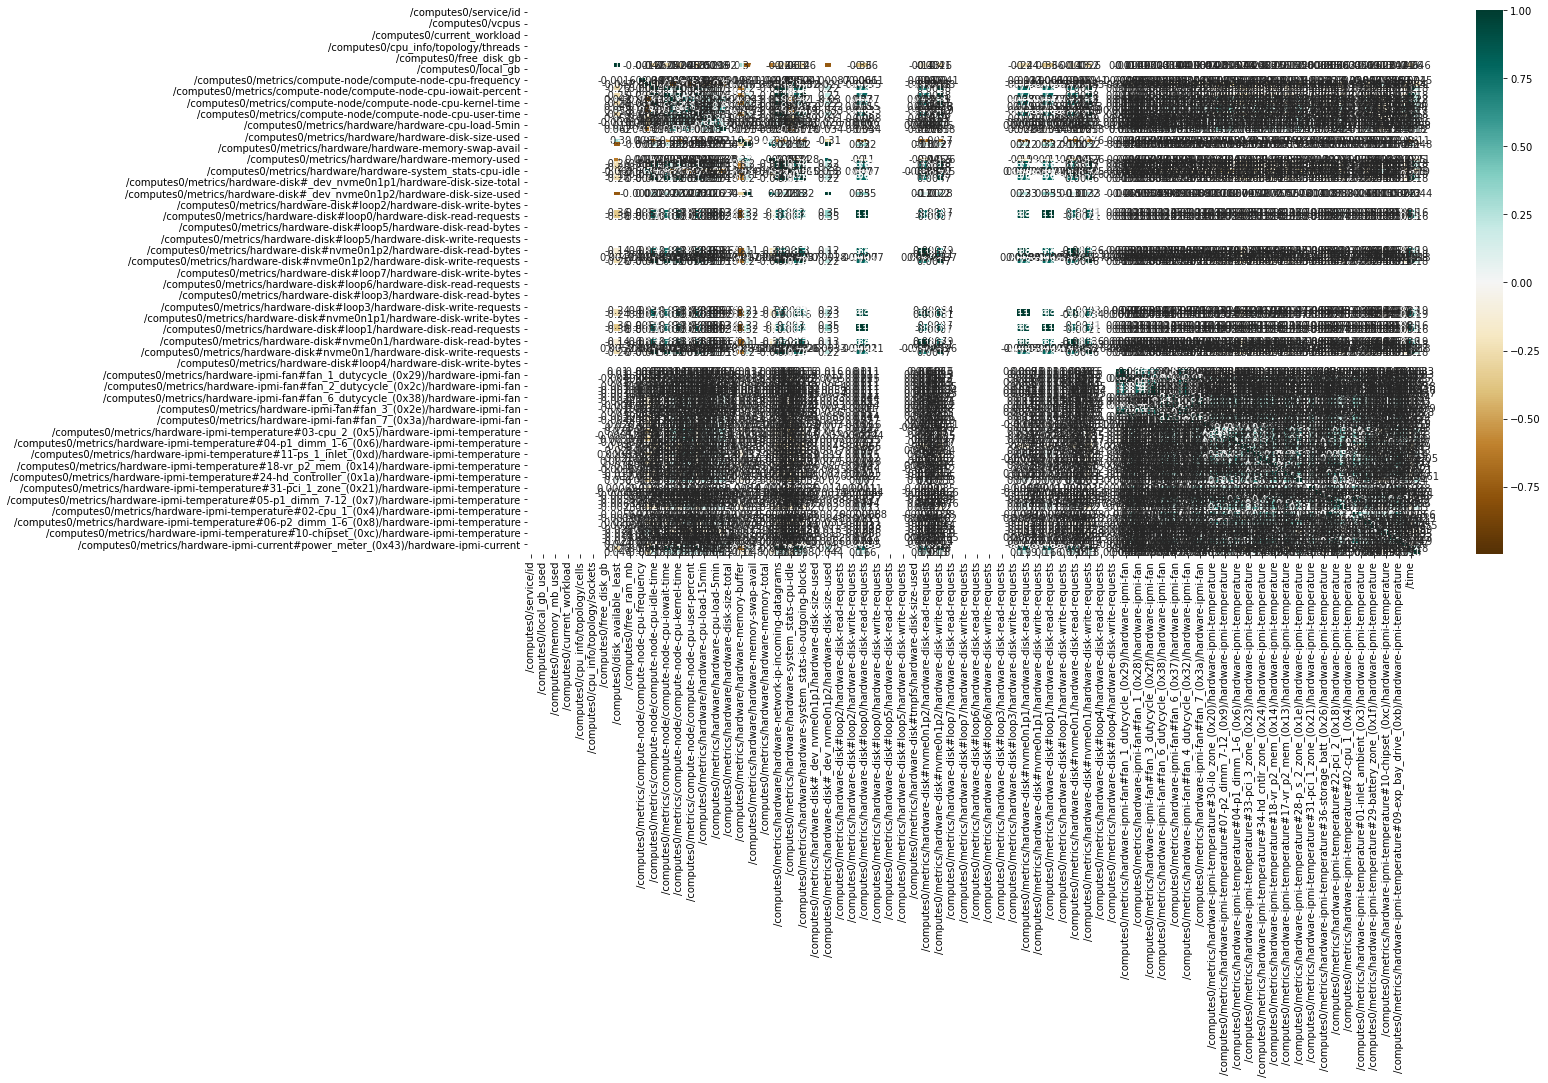

In [31]:
#Find the relations between the variables
plt.figure(figsize=(20,10))
c=df_p.corr()
sns.heatmap(c,cmap="BrBG",annot=True)
c

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import VarianceThreshold
     

In [33]:
x = df_p.drop('type', axis = 1)
y = df_p['type'] 
x.shape, y.shape
     

((9670, 144), (9670,))

In [34]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0, stratify=y)

In [35]:
constant_filter = VarianceThreshold(threshold=0)
constant_filter.fit(x_train)
     

VarianceThreshold(threshold=0)

In [36]:
constant_filter.get_support().sum()

84

In [37]:
constant_list = [not temp for temp in constant_filter.get_support()]
constant_list

[True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 False,
 True,
 True,
 True,
 False,
 False,
 False,
 True,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 True,
 True,
 False,
 False,
 True,
 True,
 True,
 False,
 False,
 False,
 False,
 False,
 False,
 True,
 True,
 True,
 False,
 True,
 True,
 True,
 True,
 False,
 False,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 False,
 False,
 False,
 False,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 False,
 False,
 True,
 True,
 False,
 False,
 True,
 True,
 False,
 False,
 False,
 False,
 True,
 True,
 True,
 True,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 True,
 False,
 False,
 False,
 False,
 False,
 False,
 Tr

In [38]:
x.columns[constant_list]

Index(['/computes0/service/id', '/computes0/vcpus_used',
       '/computes0/local_gb_used', '/computes0/vcpus',
       '/computes0/memory_mb_used', '/computes0/memory_mb',
       '/computes0/current_workload', '/computes0/cpu_info/topology/cores',
       '/computes0/cpu_info/topology/cells',
       '/computes0/cpu_info/topology/threads',
       '/computes0/cpu_info/topology/sockets', '/computes0/running_vms',
       '/computes0/free_disk_gb', '/computes0/hypervisor_version',
       '/computes0/local_gb', '/computes0/free_ram_mb', '/computes0/id',
       '/computes0/metrics/compute-node/compute-node-cpu-iowait-percent',
       '/computes0/metrics/hardware/hardware-disk-size-total',
       '/computes0/metrics/hardware/hardware-disk-size-used',
       '/computes0/metrics/hardware/hardware-memory-swap-avail',
       '/computes0/metrics/hardware/hardware-memory-swap-total',
       '/computes0/metrics/hardware/hardware-memory-total',
       '/computes0/metrics/hardware-disk#_dev_nvme0n1p1/ha

In [39]:
x_train_filter = constant_filter.transform(x_train)
x_test_filter = constant_filter.transform(x_test)

In [40]:
x_train_filter.shape, x_test_filter.shape, x_train.shape

((7736, 84), (1934, 84), (7736, 144))

In [41]:
quasi_constant_filter = VarianceThreshold(threshold=0.01)

In [42]:
quasi_constant_filter.fit(x_train_filter)

VarianceThreshold(threshold=0.01)

In [43]:
quasi_constant_filter.get_support().sum()

81

In [84]:
84-81

3

In [45]:
x_train_quasi_filter = quasi_constant_filter.transform(x_train_filter)
x_test_quasi_filter = quasi_constant_filter.transform(x_test_filter)

In [46]:
x_train_quasi_filter.shape, x_test_quasi_filter.shape

((7736, 81), (1934, 81))

In [47]:
144-74

70

In [48]:
x_train_T = x_train_quasi_filter.T
x_test_T = x_test_quasi_filter.T

In [49]:
type(x_train_T)

numpy.ndarray

In [50]:
x_train_T = pd.DataFrame(x_train_T)
x_test_T = pd.DataFrame(x_test_T)

In [51]:
x_train_T.shape, x_test_T.shape

((81, 7736), (81, 1934))

In [52]:
x_train_T.duplicated().sum()

0

In [53]:
duplicated_features = x_train_T.duplicated()
duplicated_features

0     False
1     False
2     False
3     False
4     False
      ...  
76    False
77    False
78    False
79    False
80    False
Length: 81, dtype: bool

In [54]:
features_to_keep = [not index for index in duplicated_features]

In [55]:
x_train_unique = x_train_T[features_to_keep].T
x_test_unique = x_test_T[features_to_keep].T

In [56]:
x_train_unique.shape, x_train.shape

((7736, 81), (7736, 144))

In [57]:

144-70

74

In [58]:
def run_randomForest(x_train, x_test, y_train, y_test):
  clf = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)
  clf.fit(x_train, y_train)
  y_pred = clf.predict(x_test)
  print('Accuracy on test set: ')
  print(accuracy_score(y_test, y_pred))

In [59]:
%%time 
run_randomForest(x_train_unique, x_test_unique, y_train, y_test)


Accuracy on test set: 
0.9875904860392968
CPU times: total: 2.52 s
Wall time: 515 ms


In [60]:
%%time
run_randomForest(x_train, x_test, y_train, y_test)

Accuracy on test set: 
0.983971044467425
CPU times: total: 2.27 s
Wall time: 442 ms


In [61]:
corrmat = x_train_unique.corr()

<AxesSubplot:>

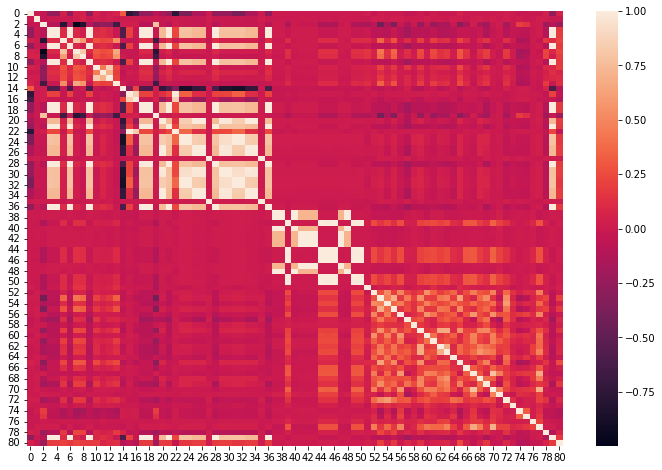

In [62]:
plt.figure(figsize=(12,8))
sns.heatmap(corrmat)

In [63]:
def get_correlation(df_p, threshold):
  corr_col = set()
  corrmat = df_p.corr()
  for i in range(len(corrmat.columns)):
    for j in range(i):
      if abs(corrmat.iloc[i, j])> threshold:
        colname = corrmat.columns[i]
        corr_col.add(colname)
  return corr_col      


In [64]:
corr_features = get_correlation(x_train_unique, 0.85)
corr_features

{4,
 6,
 7,
 9,
 17,
 18,
 21,
 22,
 23,
 24,
 25,
 26,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 38,
 40,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 79}

In [65]:
len(corr_features)

33

In [66]:
x_train_uncorr = x_train_unique.drop(labels=corr_features, axis = 1)
x_test_uncorr = x_test_unique.drop(labels=corr_features, axis = 1)


In [67]:
x_train_uncorr.shape, x_test_uncorr.shape

((7736, 48), (1934, 48))

In [68]:
%%time
run_randomForest(x_train_uncorr, x_test_uncorr, y_train, y_test)

Accuracy on test set: 
0.9860392967942089
CPU times: total: 1.72 s
Wall time: 378 ms


In [69]:
%%time
run_randomForest(x_train, x_test, y_train, y_test)

Accuracy on test set: 
0.983971044467425
CPU times: total: 2.31 s
Wall time: 518 ms


In [70]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.metrics import roc_auc_score

# Initialize the SelectKBest class with the chi2 score function and set k=5 to select the top 5 features
selector = SelectKBest(chi2, k=5)

# Fit the selector to the training data and transform the training data to get the selected features
selected_features = selector.fit_transform(x_train, y_train)

# Get the columns of the selected features
selected_features_columns = x_train.columns[selector.get_support()]

# Use the selected features for training and testing the classifier
clf = RandomForestClassifier(n_estimators=100, random_state=0)
clf.fit(selected_features, y_train)
y_prob = clf.predict_proba(x_test[selected_features_columns])
roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
print("ROC AUC score with selected features: ", roc_auc)

ROC AUC score with selected features:  0.9911157335904088


C:\Users\asus\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [71]:
# Importing necessary libraries
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

# Define Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=0)
model.fit(x_train, y_train)
# Define RFE with 5 selected features
rfe = RFE(estimator=model, n_features_to_select=5)

# Fit RFE on training data
selected_features = rfe.fit_transform(x_train, y_train)

In [72]:
x_test_selected = rfe.transform(x_test)
clf.fit(selected_features, y_train)
y_pred = clf.predict(x_test_selected)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)

Accuracy:  0.999482936918304


In [73]:
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
print("Precision: ", precision)
print("Recall: ", recall)
print("F1-score: ", f1)

Precision:  0.9995020874028112
Recall:  0.999482936918304
F1-score:  0.999486655537641


In [74]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=0)
model.fit(x_train, y_train)
importances = model.feature_importances_
selected_features = x_train[x_train.columns[importances > 0.05]]
print(selected_features)

      type_code
3807         12
3504          7
3290          8
683           5
2385          5
...         ...
8267          5
7721         12
5875          3
6021          4
8134          5

[7736 rows x 1 columns]


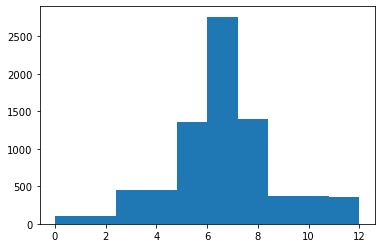

In [75]:
import matplotlib.pyplot as plt
plt.hist(selected_features['type_code'])
plt.show()

In [76]:
print(selected_features['type_code'].describe())

count    7736.000000
mean        6.540460
std         2.176425
min         0.000000
25%         5.000000
50%         6.500000
75%         8.000000
max        12.000000
Name: type_code, dtype: float64


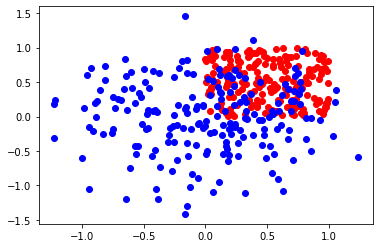

In [82]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Generate random data for PCA
np.random.seed(0)
data = np.random.rand(200, 145)

# Perform PCA
pca = PCA(n_components=145)
data_transformed = pca.fit_transform(data)

# Plot the data before and after PCA
plt.scatter(data[:, 0], data[:, 1], color='red')
plt.scatter(data_transformed[:, 0], data_transformed[:, 1], color='blue')
plt.show()